# Análisis exploratorio de créditos

## 1. Entendimiento del problema

### Contexto

Se dispone de una base de datos perteneciente a una empresa del sector financiero. El conjunto de datos contiene información relacionada con los créditos otorgados, características de los clientes y el comportamiento de pago de dichos créditos.

El propósito del análisis es comprender las características de la cartera, evaluar la calidad de la información disponible e identificar patrones que puedan resultar relevantes para la gestión del riesgo crediticio.

El conjunto de datos fue entregado sin un diccionario de datos, por lo que parte del análisis consistirá en inferir provisionalmente el significado de las variables y documentar aquellos aspectos que requieren validación con el área de negocio.

### Objetivo general

Analizar la información disponible sobre créditos y clientes con el fin de identificar problemas de calidad de datos, caracterizar el comportamiento de la cartera y encontrar factores asociados con el cumplimiento o incumplimiento oportuno de los pagos que puedan generar información útil para la toma de decisiones de la organización.

### Objetivos específicos

1. Comprender la estructura, contenido y calidad del conjunto de datos.

2. Identificar valores faltantes, inconsistencias, valores atípicos y posibles errores en las variables.

3. Caracterizar las principales variables relacionadas con los clientes y los créditos.

4. Analizar el comportamiento de la variable asociada al pago oportuno del crédito.

5. Explorar qué características presentan asociaciones con una mayor o menor frecuencia de incumplimiento.

6. Proponer reglas de validación y posibles variables derivadas que puedan ser útiles en etapas posteriores del proyecto.

7. Traducir los hallazgos técnicos en conclusiones y recomendaciones comprensibles para perfiles técnicos y de negocio.

### Variable objetivo provisional

A partir del nombre de las variables y de la descripción suministrada en el ejercicio, se identifica provisionalmente `Pago_atiempo` como la variable objetivo del análisis.

La hipótesis inicial es que esta variable representa si el pago asociado al crédito fue realizado oportunamente.

Antes de utilizarla se deben validar:

- Los valores diferentes que contiene.
- El significado exacto de cada valor.
- La definición de "pago a tiempo" utilizada por la organización.
- El momento en el que se observa el resultado.

### Preguntas iniciales de negocio

El análisis exploratorio buscará responder, entre otras, las siguientes preguntas:

1. ¿Qué proporción de los créditos fue pagada a tiempo y qué proporción presentó incumplimiento?

2. ¿Cómo se caracteriza la población de clientes y los créditos otorgados?

3. ¿Existen características de los clientes asociadas con una mayor frecuencia de incumplimiento?

4. ¿Existen características del crédito asociadas con una mayor frecuencia de incumplimiento?

5. ¿El comportamiento de pago varía entre diferentes tipos de crédito?

6. ¿Variables relacionadas con ingresos, obligaciones financieras o historial crediticio presentan diferencias entre clientes que pagan oportunamente y quienes no?

7. ¿Existen segmentos de clientes o créditos que concentren una mayor proporción de incumplimientos?

8. ¿El comportamiento de los créditos cambia a lo largo del tiempo?

9. ¿Existen problemas de calidad de datos que puedan afectar las conclusiones del análisis?

10. ¿Qué nuevas variables podrían derivarse de las existentes para representar mejor la capacidad de pago o el nivel de endeudamiento del cliente?

### Hipótesis iniciales

Antes de realizar el análisis se plantean algunas hipótesis que serán contrastadas exploratoriamente con los datos:

- Los clientes con mayor nivel de endeudamiento podrían presentar una mayor frecuencia de incumplimiento.

- Una mayor cuota respecto al ingreso disponible podría estar asociada con mayor dificultad para realizar los pagos oportunamente.

- Variables relacionadas con el historial crediticio podrían diferenciar clientes con distintos niveles de riesgo.

- El comportamiento de pago podría variar entre diferentes tipos de crédito.

- Una disminución o inestabilidad de los ingresos podría estar asociada con una mayor frecuencia de incumplimiento.

Estas hipótesis son únicamente puntos de partida para el análisis y no representan relaciones causales.

### Preguntas pendientes para el área de negocio

Debido a que no se proporcionó un diccionario de datos, se identifican las siguientes preguntas que deberían validarse antes de utilizar estos datos en un proceso productivo:

1. ¿Qué representa exactamente cada valor de `Pago_atiempo`?

2. ¿Cómo define la organización que un crédito se encuentre en mora?

3. ¿Qué representa cada código de `tipo_credito`?

4. ¿Cuál es la unidad monetaria utilizada en las variables financieras?

5. ¿Qué representa exactamente la variable `puntaje` y cuál es su rango válido?

6. ¿Qué representa `puntaje_datacredito` y existen valores utilizados como códigos especiales para información no disponible?

7. ¿Qué periodo temporal representa `huella_consulta`?

8. ¿Cómo se calcula `promedio_ingresos_datacredito`?

9. ¿Qué representa exactamente `tendencia_ingresos`?

10. ¿En qué momento fueron calculadas las variables relacionadas con saldos y mora?

11. ¿Las variables disponibles corresponden a información conocida en el momento de otorgar el crédito o incluyen información posterior?

## 2. Carga y exploración inicial de los datos

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 42

In [3]:
def encontrar_raiz_proyecto(nombre_archivo="Base_de_datos.csv"):
    ruta = Path.cwd().resolve()

    while ruta != ruta.parent:
        if (ruta / nombre_archivo).exists():
            return ruta
        ruta = ruta.parent

    raise FileNotFoundError(
        f"No se encontró {nombre_archivo} en la jerarquía del proyecto."
    )


PROJECT_ROOT = encontrar_raiz_proyecto()

DATA_PATH = PROJECT_ROOT / "Base_de_datos.csv"
CONFIG_PATH = PROJECT_ROOT / "etl_scripts" / "src" / "config.json"

print("Raíz del proyecto:", PROJECT_ROOT)
print("Ruta de datos:", DATA_PATH)
print("Ruta de configuración:", CONFIG_PATH)

Raíz del proyecto: C:\Users\mario\OneDrive\Documentos\CDP
Ruta de datos: C:\Users\mario\OneDrive\Documentos\CDP\Base_de_datos.csv
Ruta de configuración: C:\Users\mario\OneDrive\Documentos\CDP\etl_scripts\src\config.json


In [4]:
with open(CONFIG_PATH, "r", encoding="utf-8") as archivo:
    config = json.load(archivo)

config

{'data_file': 'Base_de_datos.csv',
 'separator': ';',
 'encoding': 'utf-8-sig',
 'target': 'Pago_atiempo'}

In [5]:
df_raw = pd.read_csv(
    DATA_PATH,
    sep=config["separator"],
    encoding=config["encoding"],
    dtype="string"
)

df = df_raw.copy()

In [6]:
print(f"Número de filas: {df.shape[0]:,}")
print(f"Número de columnas: {df.shape[1]}")
print(f"Duplicados completos: {df.duplicated().sum()}")

display(df.head())

Número de filas: 10,763
Número de columnas: 23
Duplicados completos: 0


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,4,7/01/2025 14:40,1852560,12,32,Empleado,3500000,1000000,128650,"95,227787",795.0,0,2,0.0,0.0,<NA>,<NA>,0,0,0,916148,Creciente,1
1,4,9/01/2025 11:18,3181080,6,34,Empleado,5000000,2000000,441817,"95,227787",796.0,0,7,0.0,0.0,<NA>,<NA>,0,0,0,4473774,Creciente,1
2,9,26/12/2024 18:52,670200,5,34,Independiente,5000000,2000000,108632,"95,227787",727,5,0,0,274561,274561,<NA>,2,0,1,<NA>,<NA>,1
3,9,4/12/2024 14:20,506807,2,25,Independiente,3000000,900000,199684,"95,227787",864,8,1,0,27564,27564,<NA>,1,0,6,<NA>,<NA>,1
4,4,30/04/2025 18:41,999780,10,26,Empleado,2000000,600000,92509,"95,227787",771.0,0,3,0.0,0.0,<NA>,<NA>,0,0,0,61000,Creciente,1


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   tipo_credito                   10763 non-null  string
 1   fecha_prestamo                 10763 non-null  string
 2   capital_prestado               10763 non-null  string
 3   plazo_meses                    10763 non-null  string
 4   edad_cliente                   10763 non-null  string
 5   tipo_laboral                   10763 non-null  string
 6   salario_cliente                10763 non-null  string
 7   total_otros_prestamos          10763 non-null  string
 8   cuota_pactada                  10763 non-null  string
 9   puntaje                        10763 non-null  string
 10  puntaje_datacredito            10757 non-null  string
 11  cant_creditosvigentes          10763 non-null  string
 12  huella_consulta                10763 non-null  string
 13  saldo_mora  

In [8]:
df.nunique(dropna=False).sort_values()

tipo_laboral                         2
Pago_atiempo                         2
saldo_mora_codeudor                  6
tipo_credito                         6
creditos_sectorCooperativo          11
plazo_meses                         18
creditos_sectorReal                 24
huella_consulta                     28
creditos_sectorFinanciero           33
cant_creditosvigentes               39
tendencia_ingresos                  47
edad_cliente                        54
saldo_mora                          58
puntaje                            248
puntaje_datacredito                473
salario_cliente                   1385
total_otros_prestamos             1538
promedio_ingresos_datacredito     5310
capital_prestado                  7306
saldo_principal                   8693
saldo_total                       8893
cuota_pactada                     9836
fecha_prestamo                   10444
dtype: int64

In [9]:
df.isna().sum().sort_values(ascending=False)

tendencia_ingresos               2932
promedio_ingresos_datacredito    2930
saldo_mora_codeudor               590
saldo_principal                   405
saldo_mora                        156
saldo_total                       156
puntaje_datacredito                 6
salario_cliente                     0
tipo_laboral                        0
edad_cliente                        0
plazo_meses                         0
capital_prestado                    0
fecha_prestamo                      0
tipo_credito                        0
total_otros_prestamos               0
cant_creditosvigentes               0
huella_consulta                     0
cuota_pactada                       0
puntaje                             0
creditos_sectorCooperativo          0
creditos_sectorFinanciero           0
creditos_sectorReal                 0
Pago_atiempo                        0
dtype: int64

### 2.1 Perfil inicial del conjunto de datos

Se realiza una caracterización inicial de las variables para identificar su tipo de dato actual, cantidad de valores faltantes, porcentaje de ausencia y cardinalidad.

En esta etapa todavía no se realizan transformaciones, ya que primero se busca comprender cómo se encuentran representados los datos originales.

In [10]:
perfil_inicial = pd.DataFrame({
    "tipo_actual": df.dtypes.astype(str),
    "cantidad_nulos": df.isna().sum(),
    "porcentaje_nulos": df.isna().mean().mul(100),
    "valores_unicos": df.nunique(dropna=True)
})

perfil_inicial = perfil_inicial.sort_values(
    by="porcentaje_nulos",
    ascending=False
)

display(perfil_inicial)

,tipo_actual,cantidad_nulos,porcentaje_nulos,valores_unicos
tendencia_ingresos,string,2932,27.24,46
promedio_ingresos_datacredito,string,2930,27.22,5309
saldo_mora_codeudor,string,590,5.48,5
saldo_principal,string,405,3.76,8692
saldo_mora,string,156,1.45,57
saldo_total,string,156,1.45,8892
puntaje_datacredito,string,6,0.06,472
salario_cliente,string,0,0.00,1385
tipo_laboral,string,0,0.00,2
edad_cliente,string,0,0.00,54


### 2.2 Inspección de variables categóricas y de baja cardinalidad

Se revisan los valores presentes en variables categóricas o con pocos valores únicos para identificar posibles dominios válidos, categorías inesperadas y códigos que requieran interpretación adicional.

In [11]:
columnas_inspeccion = [
    "Pago_atiempo",
    "tipo_laboral",
    "tipo_credito",
    "tendencia_ingresos",
    "saldo_mora_codeudor"
]

for columna in columnas_inspeccion:
    print(f"\n{'=' * 60}")
    print(f"Variable: {columna}")
    print(f"{'=' * 60}")

    display(
        df[columna]
        .value_counts(dropna=False)
        .to_frame("frecuencia")
    )


Variable: Pago_atiempo


,frecuencia
Pago_atiempo,
1,10252
0,511



Variable: tipo_laboral


,frecuencia
tipo_laboral,
Empleado,6754
Independiente,4009



Variable: tipo_credito


,frecuencia
tipo_credito,
4,7747
9,2876
10,116
6,21
7,2
68,1



Variable: tendencia_ingresos


,frecuencia
tendencia_ingresos,
Creciente,5294
<NA>,2932
Decreciente,1291
Estable,1188
0,7
8315,6
1000000,4
9147,2
158042,1



Variable: saldo_mora_codeudor


,frecuencia
saldo_mora_codeudor,
0.0,10113
<NA>,590
0,57
30.0,1
470,1
2145,1


### Hallazgos preliminares sobre dominios y representación

La inspección de las variables de baja cardinalidad permitió identificar varios aspectos relevantes:

- `Pago_atiempo` presenta únicamente los valores `0` y `1`, lo cual respalda provisionalmente su interpretación como una variable objetivo binaria.

- `tipo_laboral` contiene las categorías `Empleado` e `Independiente` y no presenta inicialmente categorías inesperadas.

- `tipo_credito` contiene seis códigos diferentes. Estos valores deben interpretarse como identificadores de categorías y no como magnitudes numéricas. Algunos códigos presentan muy pocas observaciones, por lo que sus resultados deberán interpretarse con precaución.

- `tendencia_ingresos` presenta las categorías esperadas `Creciente`, `Estable` y `Decreciente`, pero también contiene múltiples valores numéricos que no parecen corresponder con el dominio esperado de la variable. Estos registros serán considerados anomalías de dominio hasta contar con una definición oficial.

- `saldo_mora_codeudor` presenta diferentes representaciones textuales de valores numéricamente equivalentes, como `0` y `0.0`. Esto evidencia la necesidad de normalizar los tipos de datos antes de realizar análisis estadísticos.

### 2.3 Clasificación provisional de las variables

A partir del nombre de las columnas, sus valores observados y la descripción del problema, se establece una clasificación provisional de los tipos analíticos de cada variable antes de realizar las conversiones.

In [12]:
clasificacion_variables = pd.DataFrame([
    ["tipo_credito", "Categórica nominal", "Código de tipo de crédito"],
    ["fecha_prestamo", "Temporal", "Fecha y hora del crédito"],
    ["capital_prestado", "Numérica continua", "Monto prestado"],
    ["plazo_meses", "Numérica discreta", "Duración del crédito"],
    ["edad_cliente", "Numérica discreta", "Edad del cliente"],
    ["tipo_laboral", "Categórica nominal", "Tipo de vinculación laboral"],
    ["salario_cliente", "Numérica continua", "Ingreso o salario reportado"],
    ["total_otros_prestamos", "Numérica continua", "Monto de otros préstamos"],
    ["cuota_pactada", "Numérica continua", "Cuota acordada"],
    ["puntaje", "Numérica continua", "Puntaje interno por validar"],
    ["puntaje_datacredito", "Numérica u ordinal", "Puntaje externo por validar"],
    ["cant_creditosvigentes", "Numérica discreta", "Cantidad de créditos vigentes"],
    ["huella_consulta", "Numérica discreta", "Cantidad de consultas por validar"],
    ["saldo_mora", "Numérica continua", "Saldo relacionado con mora"],
    ["saldo_total", "Numérica continua", "Saldo total"],
    ["saldo_principal", "Numérica continua", "Saldo principal"],
    ["saldo_mora_codeudor", "Numérica continua", "Saldo en mora del codeudor"],
    ["creditos_sectorFinanciero", "Numérica discreta", "Cantidad de créditos"],
    ["creditos_sectorCooperativo", "Numérica discreta", "Cantidad de créditos"],
    ["creditos_sectorReal", "Numérica discreta", "Cantidad de créditos"],
    ["promedio_ingresos_datacredito", "Numérica continua", "Ingreso promedio reportado externamente"],
    ["tendencia_ingresos", "Categórica nominal", "Tendencia de ingresos"],
    ["Pago_atiempo", "Binaria", "Resultado de pago oportuno"]
], columns=[
    "variable",
    "tipo_analitico_provisional",
    "interpretacion_provisional"
])

display(clasificacion_variables)

,variable,tipo_analitico_provisional,interpretacion_provisional
0,tipo_credito,Categórica nominal,Código de tipo de crédito
1,fecha_prestamo,Temporal,Fecha y hora del crédito
2,capital_prestado,Numérica continua,Monto prestado
3,plazo_meses,Numérica discreta,Duración del crédito
4,edad_cliente,Numérica discreta,Edad del cliente
5,tipo_laboral,Categórica nominal,Tipo de vinculación laboral
6,salario_cliente,Numérica continua,Ingreso o salario reportado
7,total_otros_prestamos,Numérica continua,Monto de otros préstamos
8,cuota_pactada,Numérica continua,Cuota acordada
9,puntaje,Numérica continua,Puntaje interno por validar


### 2.4 Normalización inicial de cadenas y valores nulos

Antes de convertir los tipos de datos se normalizan espacios en blanco y representaciones textuales de valores faltantes.

No se imputan valores en esta etapa, ya que primero se busca preservar la información original y comprender el significado de la ausencia.

In [13]:
# Eliminar espacios al inicio y al final de todas las columnas de texto
for columna in df.columns:
    df[columna] = df[columna].str.strip()

# Representaciones comunes de valores faltantes
tokens_nulos = [
    "",
    " ",
    "NA",
    "N/A",
    "n/a",
    "NULL",
    "null",
    "None",
    "none",
    "NaN",
    "nan",
    "-",
    "--"
]

df = df.replace(tokens_nulos, pd.NA)

In [14]:
nulos_despues_normalizacion = pd.DataFrame({
    "cantidad_nulos": df.isna().sum(),
    "porcentaje_nulos": df.isna().mean().mul(100)
}).sort_values(
    by="porcentaje_nulos",
    ascending=False
)

display(nulos_despues_normalizacion)

,cantidad_nulos,porcentaje_nulos
tendencia_ingresos,2932,27.24
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06
salario_cliente,0,0.00
tipo_laboral,0,0.00
edad_cliente,0,0.00


### 2.5 Conversión de la variable temporal

La variable `fecha_prestamo` se convierte a un tipo de fecha y hora para permitir análisis temporales posteriores.

Se utiliza una conversión tolerante a errores para identificar registros cuyo formato no pueda interpretarse correctamente.

In [15]:
df["fecha_prestamo"] = pd.to_datetime(
    df["fecha_prestamo"],
    dayfirst=True,
    errors="coerce"
)

print("Fechas inválidas:", df["fecha_prestamo"].isna().sum())
print("Fecha mínima:", df["fecha_prestamo"].min())
print("Fecha máxima:", df["fecha_prestamo"].max())

Fechas inválidas: 0
Fecha mínima: 2024-11-26 09:17:00
Fecha máxima: 2026-04-26 18:43:00


### 2.6 Conversión de variables numéricas

Las variables identificadas provisionalmente como numéricas se convierten de texto a valores numéricos.

La conversión se realiza de manera controlada para identificar valores que no puedan interpretarse correctamente y evitar que inconsistencias de representación afecten el análisis posterior.

In [16]:
def convertir_numerico(serie):
    return pd.to_numeric(
        serie.astype("string")
             .str.strip()
             .str.replace(",", ".", regex=False),
        errors="coerce"
    )

In [17]:
columnas_numericas = [
    "capital_prestado",
    "plazo_meses",
    "edad_cliente",
    "salario_cliente",
    "total_otros_prestamos",
    "cuota_pactada",
    "puntaje",
    "puntaje_datacredito",
    "cant_creditosvigentes",
    "huella_consulta",
    "saldo_mora",
    "saldo_total",
    "saldo_principal",
    "saldo_mora_codeudor",
    "creditos_sectorFinanciero",
    "creditos_sectorCooperativo",
    "creditos_sectorReal",
    "promedio_ingresos_datacredito",
    "Pago_atiempo"
]

for columna in columnas_numericas:
    df[columna] = convertir_numerico(df[columna])

In [18]:
df[columnas_numericas].dtypes

capital_prestado                   Int64
plazo_meses                        Int64
edad_cliente                       Int64
salario_cliente                    Int64
total_otros_prestamos              Int64
cuota_pactada                      Int64
puntaje                          Float64
puntaje_datacredito              Float64
cant_creditosvigentes              Int64
huella_consulta                    Int64
saldo_mora                       Float64
saldo_total                      Float64
saldo_principal                  Float64
saldo_mora_codeudor              Float64
creditos_sectorFinanciero          Int64
creditos_sectorCooperativo         Int64
creditos_sectorReal                Int64
promedio_ingresos_datacredito      Int64
Pago_atiempo                       Int64
dtype: object

In [19]:
nulos_despues_conversion = pd.DataFrame({
    "nulos_antes": df_raw[columnas_numericas].isna().sum(),
    "nulos_despues": df[columnas_numericas].isna().sum()
})

nulos_despues_conversion["nuevos_nulos_conversion"] = (
    nulos_despues_conversion["nulos_despues"]
    - nulos_despues_conversion["nulos_antes"]
)

display(
    nulos_despues_conversion.sort_values(
        "nuevos_nulos_conversion",
        ascending=False
    )
)

,nulos_antes,nulos_despues,nuevos_nulos_conversion
capital_prestado,0,0,0
plazo_meses,0,0,0
edad_cliente,0,0,0
salario_cliente,0,0,0
total_otros_prestamos,0,0,0
cuota_pactada,0,0,0
puntaje,0,0,0
puntaje_datacredito,6,6,0
cant_creditosvigentes,0,0,0
huella_consulta,0,0,0


### Resultado de la conversión numérica

La conversión de las variables numéricas no generó nuevos valores nulos.

Esto indica que todos los valores no nulos presentes en estas columnas pudieron interpretarse correctamente como datos numéricos después de normalizar su representación.

Los valores faltantes existentes corresponden a ausencias que ya estaban presentes en los datos originales y no fueron producidos por la transformación.

In [20]:
columnas_categoricas = [
    "tipo_credito",
    "tipo_laboral",
    "tendencia_ingresos"
]

for columna in columnas_categoricas:
    df[columna] = df[columna].astype("category")

In [21]:
df.dtypes

tipo_credito                           category
fecha_prestamo                   datetime64[us]
capital_prestado                          Int64
plazo_meses                               Int64
edad_cliente                              Int64
tipo_laboral                           category
salario_cliente                           Int64
total_otros_prestamos                     Int64
cuota_pactada                             Int64
puntaje                                 Float64
puntaje_datacredito                     Float64
cant_creditosvigentes                     Int64
huella_consulta                           Int64
saldo_mora                              Float64
saldo_total                             Float64
saldo_principal                         Float64
saldo_mora_codeudor                     Float64
creditos_sectorFinanciero                 Int64
creditos_sectorCooperativo                Int64
creditos_sectorReal                       Int64
promedio_ingresos_datacredito           

### 2.7 Validación de reglas de calidad

Una vez ajustados los tipos de datos, se revisan reglas básicas de consistencia y dominio para identificar registros potencialmente anómalos.

Estas reglas son provisionales y algunas deben ser validadas con el área de negocio antes de utilizarse en un proceso productivo.

In [22]:
reglas_calidad = pd.DataFrame([
    {
        "variable": "Pago_atiempo",
        "regla": "Debe pertenecer a {0, 1}",
        "tipo_regla": "Dominio"
    },
    {
        "variable": "edad_cliente",
        "regla": "Debe estar provisionalmente entre 18 y 100 años",
        "tipo_regla": "Negocio provisional"
    },
    {
        "variable": "capital_prestado",
        "regla": "Debe ser mayor que 0",
        "tipo_regla": "Negocio provisional"
    },
    {
        "variable": "plazo_meses",
        "regla": "Debe ser mayor que 0",
        "tipo_regla": "Negocio provisional"
    },
    {
        "variable": "salario_cliente",
        "regla": "Debe ser mayor que 0",
        "tipo_regla": "Negocio provisional"
    },
    {
        "variable": "huella_consulta",
        "regla": "Debe ser un conteo no negativo",
        "tipo_regla": "Estructural"
    },
    {
        "variable": "tendencia_ingresos",
        "regla": "Debe pertenecer a Creciente, Estable o Decreciente",
        "tipo_regla": "Dominio"
    }
])

display(reglas_calidad)

,variable,regla,tipo_regla
0,Pago_atiempo,"Debe pertenecer a {0, 1}",Dominio
1,edad_cliente,Debe estar provisionalmente entre 18 y 100 años,Negocio provisional
2,capital_prestado,Debe ser mayor que 0,Negocio provisional
3,plazo_meses,Debe ser mayor que 0,Negocio provisional
4,salario_cliente,Debe ser mayor que 0,Negocio provisional
5,huella_consulta,Debe ser un conteo no negativo,Estructural
6,tendencia_ingresos,"Debe pertenecer a Creciente, Estable o Decreci...",Dominio


In [23]:
df["flag_target_invalido"] = ~df["Pago_atiempo"].isin([0, 1])

df["flag_edad_fuera_rango"] = ~df["edad_cliente"].between(18, 100)

df["flag_capital_no_positivo"] = df["capital_prestado"] <= 0

df["flag_plazo_no_positivo"] = df["plazo_meses"] <= 0

df["flag_salario_no_positivo"] = df["salario_cliente"] <= 0

df["flag_huella_negativa"] = df["huella_consulta"] < 0

categorias_tendencia_validas = [
    "Creciente",
    "Estable",
    "Decreciente"
]

df["flag_tendencia_invalida"] = (
    df["tendencia_ingresos"].notna()
    & ~df["tendencia_ingresos"].isin(categorias_tendencia_validas)
)

In [24]:
columnas_flags = [
    columna
    for columna in df.columns
    if columna.startswith("flag_")
]

resumen_anomalias = pd.DataFrame({
    "regla": columnas_flags,
    "registros_afectados": [
        int(df[columna].sum())
        for columna in columnas_flags
    ],
    "porcentaje": [
        df[columna].mean() * 100
        for columna in columnas_flags
    ]
}).sort_values(
    "registros_afectados",
    ascending=False
)

display(resumen_anomalias)

,regla,registros_afectados,porcentaje
1,flag_edad_fuera_rango,150,1.39
6,flag_tendencia_invalida,58,0.54
4,flag_salario_no_positivo,24,0.22
2,flag_capital_no_positivo,0,0.00
0,flag_target_invalido,0,0.00
3,flag_plazo_no_positivo,0,0.00
5,flag_huella_negativa,0,0.00


### Interpretación de las reglas de calidad

La validación inicial permitió identificar tres grupos principales de anomalías:

- Se encontraron 150 registros con edades fuera del rango provisional de 18 a 100 años, equivalentes aproximadamente al 1,39 % del conjunto de datos.

- Se identificaron 58 registros con valores no válidos en `tendencia_ingresos`, equivalentes aproximadamente al 0,54 %. Estos valores no corresponden a las categorías esperadas `Creciente`, `Estable` o `Decreciente`.

- Se encontraron 24 registros con valores de `salario_cliente` menores o iguales a cero, equivalentes aproximadamente al 0,22 %.

Por otro lado, no se encontraron valores inválidos en la variable objetivo, ni capitales o plazos no positivos, ni valores negativos en `huella_consulta`.

Estas anomalías se conservarán inicialmente y serán analizadas antes de tomar una decisión de exclusión, corrección o imputación.

In [25]:
print("Edades fuera de rango:")
display(
    df.loc[
        df["flag_edad_fuera_rango"],
        ["edad_cliente"]
    ]["edad_cliente"].value_counts().sort_index()
)

print("\nSalarios no positivos:")
display(
    df.loc[
        df["flag_salario_no_positivo"],
        ["salario_cliente"]
    ]["salario_cliente"].value_counts().sort_index()
)

print("\nTendencias inválidas:")
display(
    df.loc[
        df["flag_tendencia_invalida"],
        ["tendencia_ingresos"]
    ]["tendencia_ingresos"].value_counts()
)

Edades fuera de rango:


edad_cliente
121      4
122    144
123      2
Name: count, dtype: Int64


Salarios no positivos:


salario_cliente
0    24
Name: count, dtype: Int64


Tendencias inválidas:


tendencia_ingresos
0              7
8315           6
1000000        4
9147           2
-101368        1
-164315        1
-224714        1
-28589         1
-288           1
-4105          1
-435177        1
-566272        1
-702927        1
-70715         1
10808          1
1123000        1
122727         1
146918         1
15090          1
15245          1
158042         1
168750         1
17181          1
173031         1
1817052        1
2029000        1
209090         1
22363          1
22832          1
24702          1
31837          1
3978           1
417087         1
4250635        1
52862          1
54683          1
5697           1
65988          1
75761          1
77975          1
82657          1
86286          1
9090           1
Creciente      0
Decreciente    0
Estable        0
Name: count, dtype: int64

### Interpretación de las anomalías detectadas

La revisión de las reglas de calidad permitió identificar anomalías concretas que requieren validación antes de realizar transformaciones definitivas sobre los datos.

En `edad_cliente` se encontraron 150 registros fuera del rango provisional de 18 a 100 años. La mayoría de estos casos corresponde al valor 122, lo cual sugiere que podría tratarse de un valor codificado, un valor por defecto o un error de origen, más que de una edad real.

En `salario_cliente` se identificaron 24 registros con valor igual a cero. Aunque estos registros no necesariamente representan un error, deben tratarse con precaución, especialmente al construir variables derivadas como la relación entre cuota e ingreso.

Por otro lado, `tendencia_ingresos` presenta 58 valores fuera del dominio esperado. Además de las categorías `Creciente`, `Estable` y `Decreciente`, se encontraron múltiples valores numéricos positivos y negativos que no parecen corresponder con la naturaleza categórica de la variable. Estos casos se consideran anomalías de dominio y requieren validación con el área de negocio.

En esta etapa no se eliminan ni corrigen automáticamente estos registros. Se conservan para mantener trazabilidad y evitar introducir supuestos no confirmados sobre el significado real de los datos.

### 2.8 Revisión de valores extremos en variables numéricas

Además de las reglas de dominio, se revisan las distribuciones y valores extremos de algunas variables numéricas relevantes.

El objetivo en esta etapa no es eliminar automáticamente los valores atípicos, sino identificarlos, cuantificarlos y determinar cuáles requieren validación adicional con el área de negocio.

In [26]:
variables_revision_extremos = [
    "capital_prestado",
    "salario_cliente",
    "total_otros_prestamos",
    "cuota_pactada",
    "puntaje",
    "puntaje_datacredito",
    "huella_consulta",
    "saldo_mora",
    "saldo_total",
    "saldo_principal",
    "promedio_ingresos_datacredito"
]

resumen_extremos = df[variables_revision_extremos].describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99
    ]
).T

display(resumen_extremos)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
capital_prestado,"10,763.00","2,434,315.00","1,909,642.76","360,000.00","468,476.66","639,708.00","1,224,831.00","1,921,920.00","3,084,840.00","5,938,828.00","8,881,109.76","41,444,153.00"
salario_cliente,"10,763.00","17,216,431.46","355,476,717.60",0.00,"954,263.00","1,200,000.00","2,000,000.00","3,000,000.00","4,875,808.00","10,000,000.00","39,553,562.18","22,000,000,000.00"
total_otros_prestamos,"10,763.00","6,238,869.65","118,418,316.94",0.00,0.00,"72,100.00","500,000.00","1,000,000.00","2,000,000.00","4,798,900.00","17,946,060.00","6,787,675,263.00"
cuota_pactada,"10,763.00","243,617.41","210,493.69","23,944.00","51,439.94","71,242.00","121,041.50","182,863.00","287,833.50","610,395.30","1,114,004.42","3,816,752.00"
puntaje,"10,763.00",91.17,16.47,-38.01,-4.73,68.59,95.23,95.23,95.23,95.23,95.23,95.23
puntaje_datacredito,"10,757.00",780.79,104.88,-7.00,0.00,710.00,757.00,791.00,825.00,873.00,900.00,999.00
huella_consulta,"10,763.00",4.23,3.06,0.00,0.00,0.00,2.00,4.00,6.00,10.00,15.00,29.00
saldo_mora,"10,607.00",7.75,225.96,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"12,534.00"
saldo_total,"10,607.00","45,937.41","106,269.79",0.00,0.00,0.00,"2,898.00","16,178.00","52,982.00","186,058.70","367,295.26","5,116,066.00"
saldo_principal,"10,358.00","40,346.17","71,242.44",0.00,0.00,0.00,"2,690.00","14,442.50","47,632.25","167,037.65","325,711.87","1,562,285.00"


In [27]:
variables_clave_extremos = [
    "salario_cliente",
    "capital_prestado",
    "total_otros_prestamos",
    "puntaje",
    "puntaje_datacredito",
    "promedio_ingresos_datacredito"
]

for columna in variables_clave_extremos:
    print(f"\n{'=' * 60}")
    print(f"Variable: {columna}")
    print(f"{'=' * 60}")

    print("5 valores más pequeños:")
    display(df[columna].nsmallest(5))

    print("5 valores más grandes:")
    display(df[columna].nlargest(5))


Variable: salario_cliente
5 valores más pequeños:


125    0
281    0
380    0
445    0
446    0
Name: salario_cliente, dtype: Int64

5 valores más grandes:


5515     22000000000
2737     16991100000
10476    13258352050
10505    12450806583
10503     8252584000
Name: salario_cliente, dtype: Int64


Variable: capital_prestado
5 valores más pequeños:


...

10236   999.00
10332   987.00
19      978.00
10635   969.00
10681   968.00
Name: puntaje_datacredito, dtype: Float64


Variable: promedio_ingresos_datacredito
5 valores más pequeños:


1522    0
2852    0
3154    0
3877    0
5446    0
Name: promedio_ingresos_datacredito, dtype: Int64

5 valores más grandes:


7267     38106581
10691    28889623
426      28878675
4397     24376313
591      24047145
Name: promedio_ingresos_datacredito, dtype: Int64

### Interpretación de los valores extremos

La revisión de las variables numéricas evidencia distribuciones fuertemente asimétricas y algunos valores que requieren validación adicional antes de realizar análisis posteriores.

En `salario_cliente` se observa una diferencia considerable entre la mediana, cercana a 3 millones, y la media, superior a 17 millones. El percentil 99 se encuentra alrededor de 39,6 millones, mientras que el valor máximo alcanza 22.000 millones. Esta diferencia indica que una cantidad reducida de observaciones extremadamente altas está afectando considerablemente la media. Estos registros deben ser investigados antes de determinar si corresponden a clientes con ingresos excepcionalmente altos, errores de digitación o problemas en el origen de los datos.

`capital_prestado` presenta una distribución menos extrema. Su mediana se encuentra alrededor de 1,9 millones y el percentil 99 cerca de 8,9 millones, mientras que el máximo es aproximadamente 41,4 millones. Aunque existen créditos considerablemente superiores al comportamiento habitual de la cartera, estos valores no pueden considerarse errores únicamente por su magnitud.

En `total_otros_prestamos` se observa nuevamente una fuerte asimetría. La mediana es cercana a 1 millón y el percentil 99 aproximadamente 17,9 millones, pero el máximo supera los 6.700 millones. Esta diferencia justifica revisar los registros más extremos y confirmar la unidad monetaria y la definición exacta de la variable.

La variable `puntaje` presenta un comportamiento particularmente llamativo. Su mediana, percentiles superiores y valor máximo se concentran alrededor de 95,23, mientras que existen también valores negativos, con un mínimo aproximado de -38. Esto podría indicar que la variable contiene un valor por defecto, un límite superior, una transformación previa o una escala cuyo significado debe ser validado con el área de negocio.

En `puntaje_datacredito` la mayoría de observaciones se concentra en valores positivos, con una mediana cercana a 791. Sin embargo, se identificaron valores iguales a cero, un mínimo de -7 y valores máximos cercanos a 999. Antes de utilizar esta variable como indicador de riesgo es necesario confirmar el rango oficial y determinar si valores como `0`, `-7` o `999` representan puntajes válidos o códigos especiales.

Finalmente, `promedio_ingresos_datacredito` también presenta asimetría, aunque de menor magnitud que `salario_cliente`. Su mediana se encuentra alrededor de 1,2 millones, el percentil 99 cerca de 10,8 millones y el máximo alrededor de 38,1 millones.

En conclusión, los valores extremos no serán eliminados automáticamente. Se mantendrán durante esta etapa y se documentarán como observaciones que requieren validación. Para los análisis posteriores se priorizarán estadísticas robustas como la mediana, los cuartiles y los percentiles, evitando depender exclusivamente de la media.

### 2.9 Revisión específica de variables de puntaje

Debido a que las variables `puntaje` y `puntaje_datacredito` podrían tener relevancia para la evaluación de riesgo, se realiza una inspección detallada de su distribución, frecuencia de valores y posibles códigos especiales.

In [28]:
print("Frecuencias más comunes de puntaje:")
display(
    df["puntaje"]
    .value_counts(dropna=False)
    .head(15)
    .to_frame("frecuencia")
)

print("\nFrecuencias más comunes de puntaje_datacredito:")
display(
    df["puntaje_datacredito"]
    .value_counts(dropna=False)
    .head(15)
    .to_frame("frecuencia")
)

Frecuencias más comunes de puntaje:


,frecuencia
puntaje,
95.23,9407
89.98,99
89.23,82
92.00,73
47.61,59
84.73,59
91.73,56
92.23,51
90.56,46



Frecuencias más comunes de puntaje_datacredito:


,frecuencia
puntaje_datacredito,
0.00,145
802.00,102
783.00,102
791.00,100
801.00,98
804.00,98
769.00,95
796.00,93
814.00,92


In [29]:
valor_mas_comun_puntaje = df["puntaje"].mode(dropna=True).iloc[0]
frecuencia_moda_puntaje = (df["puntaje"] == valor_mas_comun_puntaje).sum()
porcentaje_moda_puntaje = frecuencia_moda_puntaje / len(df) * 100

print("Valor más común de puntaje:", valor_mas_comun_puntaje)
print("Frecuencia:", frecuencia_moda_puntaje)
print(f"Porcentaje del dataset: {porcentaje_moda_puntaje:.2f}%")

Valor más común de puntaje: 95.227787
Frecuencia: 9407
Porcentaje del dataset: 87.40%


In [30]:
print("Valores sospechosos en puntaje:")
print("Negativos:", (df["puntaje"] < 0).sum())
print("Iguales a cero:", (df["puntaje"] == 0).sum())

print("\nValores sospechosos en puntaje_datacredito:")
print("Negativos:", (df["puntaje_datacredito"] < 0).sum())
print("Iguales a cero:", (df["puntaje_datacredito"] == 0).sum())
print("Iguales a 999:", (df["puntaje_datacredito"] == 999).sum())

Valores sospechosos en puntaje:
Negativos: 135
Iguales a cero: 0

Valores sospechosos en puntaje_datacredito:
Negativos: 1
Iguales a cero: 145
Iguales a 999: 1


### Interpretación de las variables de puntaje

La revisión detallada evidencia comportamientos significativamente diferentes entre `puntaje` y `puntaje_datacredito`.

En `puntaje`, aproximadamente el 87,40 % de los registros presenta exactamente el mismo valor, cercano a 95,23. Esta concentración extremadamente alta indica que la variable posee poca variabilidad efectiva y podría estar utilizando un valor por defecto, una imputación previa o alguna transformación cuyo significado no se conoce. Adicionalmente, se identificaron 135 valores negativos.

Debido a este comportamiento, `puntaje` no debería considerarse inicialmente como una variable confiable para segmentación o modelado hasta conocer su definición y proceso de generación.

Por otro lado, `puntaje_datacredito` presenta una distribución considerablemente más variada. Sin embargo, se identificaron 145 registros con valor igual a cero, un registro con valor negativo y un registro con valor igual a 999.

Estos valores no serán considerados automáticamente como errores, debido a que podrían corresponder a códigos especiales utilizados por la fuente de información. Se recomienda validar con el área de negocio cuál es el rango oficial del puntaje y el significado de dichos valores antes de aplicar correcciones o exclusiones.

## 3. Análisis exploratorio de datos (EDA)

### 3.1 Análisis de la variable objetivo

Se analiza inicialmente la distribución de `Pago_atiempo` para comprender la frecuencia de cada clase y determinar si existe desbalance entre pagos oportunos e incumplimientos.

In [31]:
distribucion_target = (
    df["Pago_atiempo"]
    .value_counts()
    .sort_index()
    .to_frame("cantidad")
)

distribucion_target["porcentaje"] = (
    distribucion_target["cantidad"] / len(df) * 100
)

display(distribucion_target)

,cantidad,porcentaje
Pago_atiempo,,
0,511,4.75
1,10252,95.25


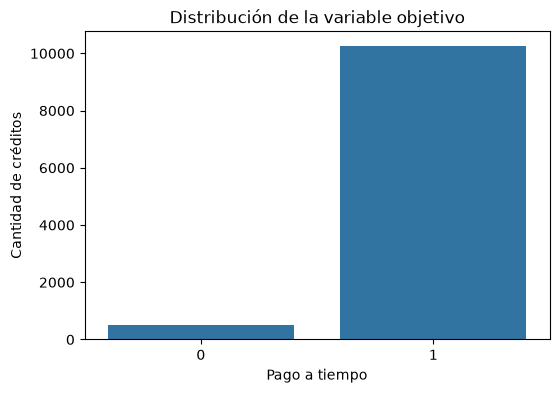

In [32]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Pago_atiempo"
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Pago a tiempo")
plt.ylabel("Cantidad de créditos")

plt.show()

### Interpretación de la variable objetivo

La variable `Pago_atiempo` presenta un desbalance considerable entre sus dos clases.

El 95,25 % de los créditos se encuentra en la categoría `1`, mientras que únicamente el 4,75 % pertenece a la categoría `0`.

Asumiendo provisionalmente que `1` representa pago oportuno y `0` representa incumplimiento, la mayor parte de la cartera presenta un comportamiento de pago favorable, mientras que los incumplimientos representan una proporción reducida del total.

Este desbalance es especialmente relevante para una eventual etapa de modelado predictivo. Un modelo que clasificara todos los créditos como pagos oportunos podría alcanzar una exactitud cercana al 95 % sin identificar correctamente ningún caso de incumplimiento. Por esta razón, métricas como `recall`, `precision`, `F1-score`, matriz de confusión o PR-AUC serían más informativas que utilizar únicamente `accuracy`.

### Creación de una variable auxiliar de incumplimiento

Para facilitar la interpretación de los análisis posteriores se crea una variable auxiliar denominada `incumplio`, donde el valor `1` representa un crédito que no fue pagado a tiempo y el valor `0` representa un pago oportuno.

Esta variable no reemplaza la variable objetivo original; únicamente permite expresar las tasas de riesgo de una forma más intuitiva.

In [33]:
df["incumplio"] = (df["Pago_atiempo"] == 0).astype(int)

df[["Pago_atiempo", "incumplio"]].value_counts().sort_index()

Pago_atiempo  incumplio
0             1              511
1             0            10252
Name: count, dtype: int64

In [34]:
print(f"Tasa global de incumplimiento: {df['incumplio'].mean() * 100:.2f}%")

Tasa global de incumplimiento: 4.75%


### 3.2 Análisis univariable

Se analizan individualmente las principales variables numéricas y categóricas con el objetivo de comprender su distribución, tendencia central, dispersión, presencia de valores extremos y composición de la cartera.

Para las variables numéricas se priorizan medidas robustas como la mediana, los cuartiles y los percentiles debido a la presencia de distribuciones asimétricas y valores extremos.

In [36]:
def analizar_numerica(dataframe, columna):
    datos = dataframe[columna].dropna()

    print(f"Variable: {columna}")
    print(f"Observaciones: {len(datos):,}")
    print(f"Nulos: {dataframe[columna].isna().sum():,}")
    print(f"Media: {datos.mean():,.2f}")
    print(f"Mediana: {datos.median():,.2f}")
    print(f"Desviación estándar: {datos.std():,.2f}")
    print(f"Mínimo: {datos.min():,.2f}")
    print(f"Máximo: {datos.max():,.2f}")
    print(f"Sesgo: {datos.skew():,.2f}")
    print(f"Curtosis: {datos.kurt():,.2f}")

    display(
        datos.describe(
            percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
        ).to_frame("valor")
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(datos, kde=True, ax=axes[0])
    axes[0].set_title(f"Distribución de {columna}")

    sns.boxplot(x=datos, ax=axes[1])
    axes[1].set_title(f"Boxplot de {columna}")

    plt.tight_layout()
    plt.show()

Variable: capital_prestado
Observaciones: 10,763
Nulos: 0
Media: 2,434,315.00
Mediana: 1,921,920.00
Desviación estándar: 1,909,642.76
Mínimo: 360,000.00
Máximo: 41,444,153.00
Sesgo: 3.72
Curtosis: 35.32


,valor
count,"10,763.00"
mean,"2,434,315.00"
std,"1,909,642.76"
min,"360,000.00"
1%,"468,476.66"
5%,"639,708.00"
25%,"1,224,831.00"
50%,"1,921,920.00"
75%,"3,084,840.00"
95%,"5,938,828.00"


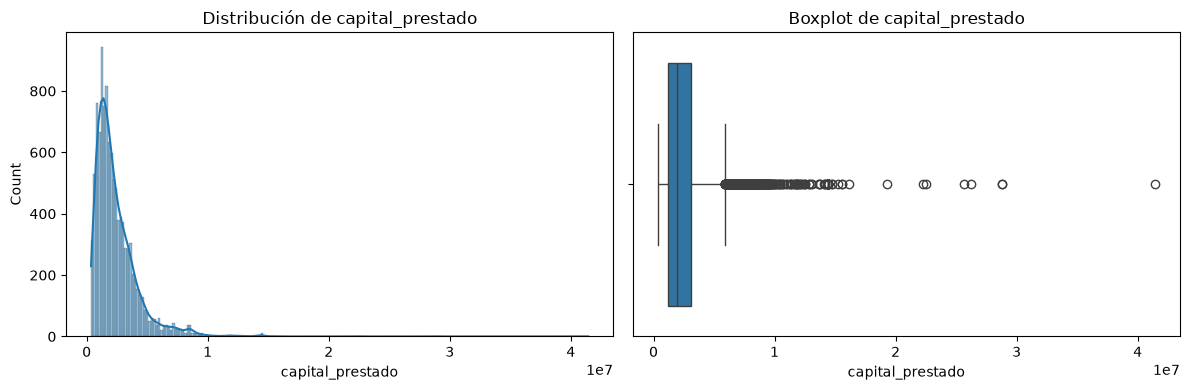

Variable: edad_cliente
Observaciones: 10,763
Nulos: 0
Media: 43.95
Mediana: 42.00
Desviación estándar: 15.06
Mínimo: 19.00
Máximo: 123.00
Sesgo: 1.93
Curtosis: 7.87


,valor
count,"10,763.00"
mean,43.95
std,15.06
min,19.00
1%,22.00
5%,25.00
25%,33.00
50%,42.00
75%,53.00
95%,65.00


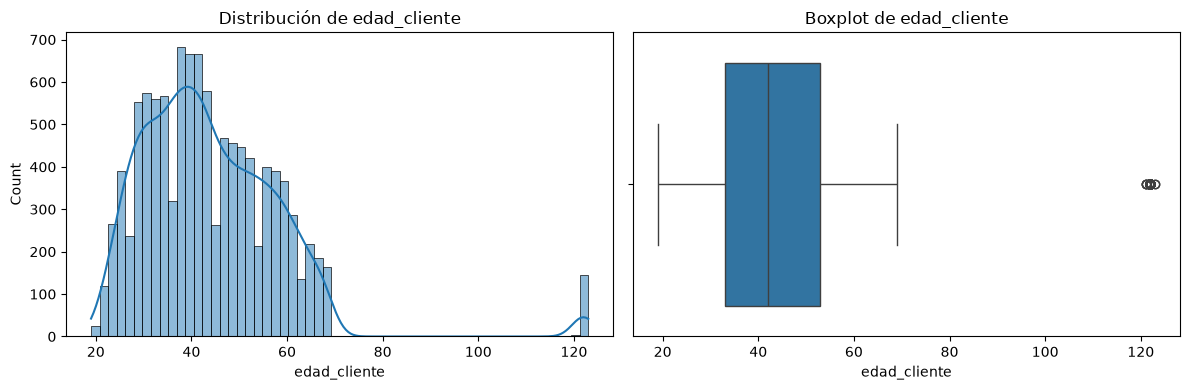

Variable: plazo_meses
Observaciones: 10,763
Nulos: 0
Media: 10.58
Mediana: 10.00
Desviación estándar: 6.63
Mínimo: 2.00
Máximo: 90.00
Sesgo: 2.46
Curtosis: 7.78


,valor
count,"10,763.00"
mean,10.58
std,6.63
min,2.00
1%,2.00
5%,5.00
25%,6.00
50%,10.00
75%,12.00
95%,24.00


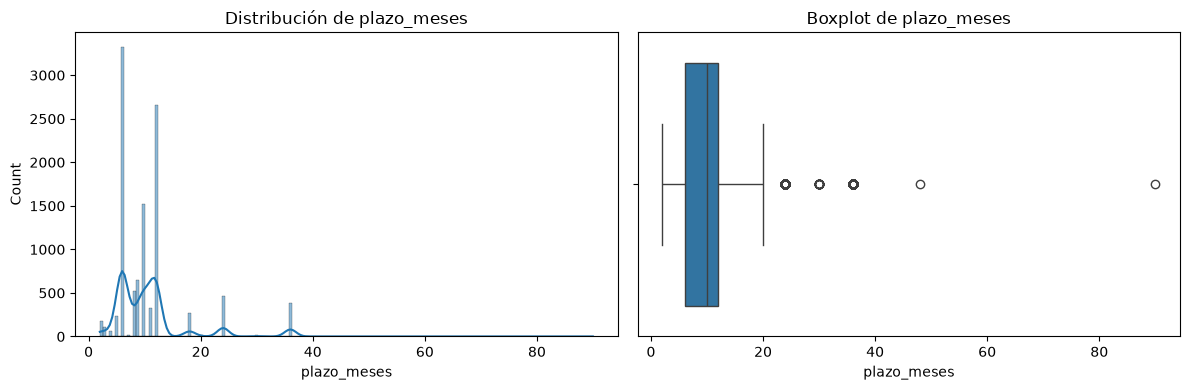

In [37]:
analizar_numerica(df, "capital_prestado")
analizar_numerica(df, "edad_cliente")
analizar_numerica(df, "plazo_meses")

### Interpretación de capital, edad y plazo

`capital_prestado` presenta una distribución asimétrica hacia la derecha. La mediana se encuentra alrededor de 1,92 millones, mientras que la media es aproximadamente 2,43 millones, lo que indica que algunos créditos de mayor monto elevan el promedio. El 95 % de los créditos se encuentra por debajo de aproximadamente 5,94 millones y el 99 % por debajo de 8,88 millones, aunque existen valores considerablemente superiores, con un máximo cercano a 41,4 millones.

En `edad_cliente`, la mediana es de 42 años y la mayor parte de los clientes se concentra aproximadamente entre 33 y 53 años. Sin embargo, se observa un grupo aislado de registros con edades de 121 a 123 años, previamente identificado como una anomalía de calidad. Estos valores explican parte de la asimetría y deben excluirse de interpretaciones demográficas hasta que sean validados.

Por su parte, `plazo_meses` se concentra principalmente en plazos cortos. La mediana es de 10 meses y el 75 % de los créditos tiene una duración de hasta 12 meses. Existen algunos contratos con plazos considerablemente mayores, alcanzando hasta 90 meses. Estos casos representan una pequeña proporción de la cartera y requieren ser analizados considerando el tipo y monto del crédito.

En conjunto, las tres variables presentan asimetría positiva, por lo que para describir el comportamiento típico de la cartera resulta más apropiado complementar la media con estadísticas robustas como la mediana y los percentiles.

Variable: salario_cliente
Observaciones: 10,763
Nulos: 0
Media: 17,216,431.46
Mediana: 3,000,000.00
Desviación estándar: 355,476,717.60
Mínimo: 0.00
Máximo: 22,000,000,000.00
Sesgo: 43.78
Curtosis: 2,211.23


,valor
count,"10,763.00"
mean,"17,216,431.46"
std,"355,476,717.60"
min,0.00
1%,"954,263.00"
5%,"1,200,000.00"
25%,"2,000,000.00"
50%,"3,000,000.00"
75%,"4,875,808.00"
95%,"10,000,000.00"


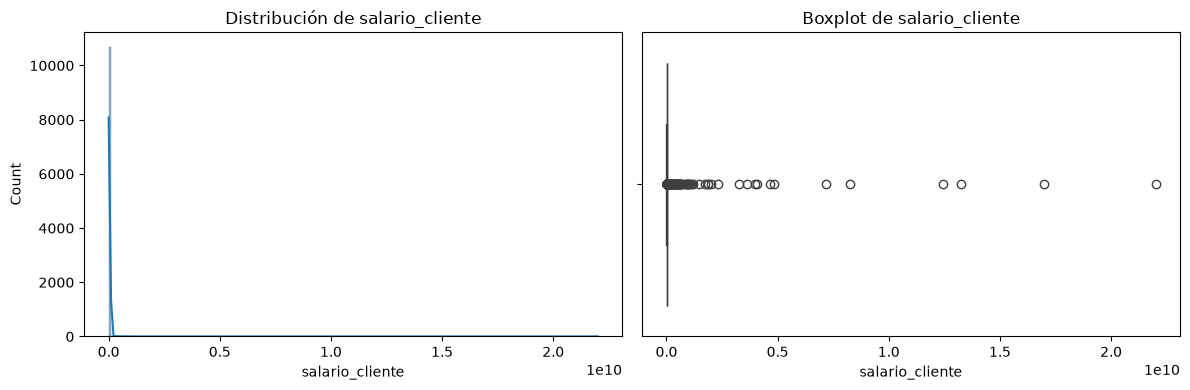

Variable: cuota_pactada
Observaciones: 10,763
Nulos: 0
Media: 243,617.41
Mediana: 182,863.00
Desviación estándar: 210,493.69
Mínimo: 23,944.00
Máximo: 3,816,752.00
Sesgo: 3.79
Curtosis: 26.65


,valor
count,"10,763.00"
mean,"243,617.41"
std,"210,493.69"
min,"23,944.00"
1%,"51,439.94"
5%,"71,242.00"
25%,"121,041.50"
50%,"182,863.00"
75%,"287,833.50"
95%,"610,395.30"


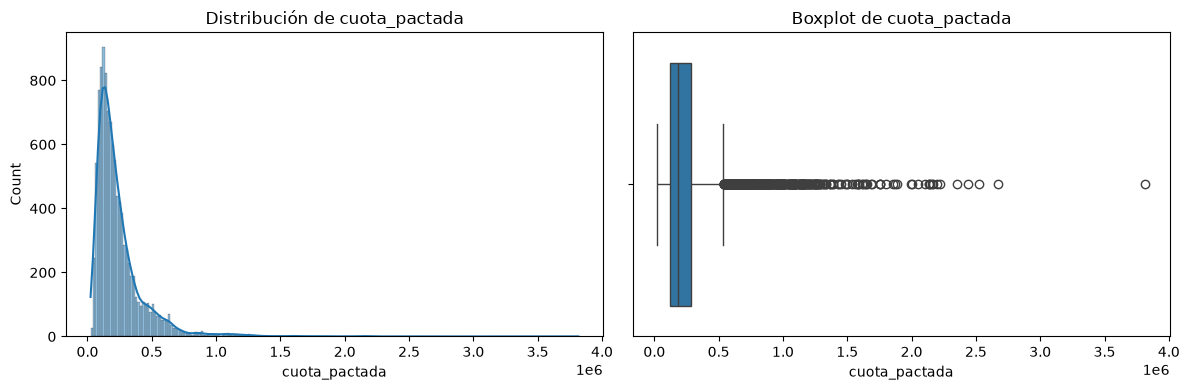

Variable: total_otros_prestamos
Observaciones: 10,763
Nulos: 0
Media: 6,238,869.65
Mediana: 1,000,000.00
Desviación estándar: 118,418,316.94
Mínimo: 0.00
Máximo: 6,787,675,263.00
Sesgo: 38.46
Curtosis: 1,719.28


,valor
count,"10,763.00"
mean,"6,238,869.65"
std,"118,418,316.94"
min,0.00
1%,0.00
5%,"72,100.00"
25%,"500,000.00"
50%,"1,000,000.00"
75%,"2,000,000.00"
95%,"4,798,900.00"


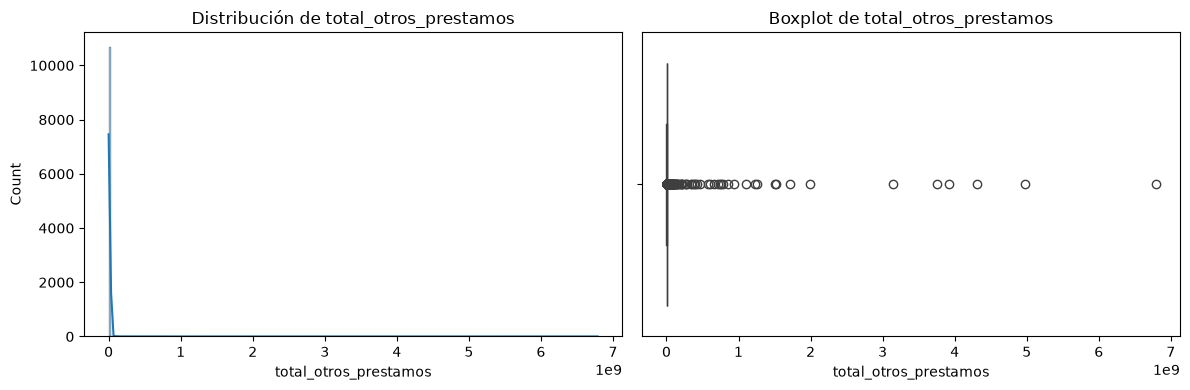

In [38]:
analizar_numerica(df, "salario_cliente")
analizar_numerica(df, "cuota_pactada")
analizar_numerica(df, "total_otros_prestamos")

### Interpretación de salario, cuota y otros préstamos

`salario_cliente` presenta una distribución extremadamente asimétrica hacia la derecha. La mediana es de aproximadamente 3 millones, mientras que la media supera los 17 millones. Esta diferencia está explicada por una pequeña cantidad de valores muy altos, con un máximo de 22.000 millones. Debido a esta distorsión, la mediana representa mejor el comportamiento típico de los ingresos que la media.

`cuota_pactada` también presenta asimetría positiva, aunque menos extrema. La mediana se encuentra alrededor de 182 mil, el percentil 95 cerca de 610 mil y el percentil 99 alrededor de 1,1 millones. La mayoría de las cuotas se concentra en valores relativamente bajos, mientras que un grupo reducido presenta cuotas considerablemente mayores.

Por su parte, `total_otros_prestamos` muestra una distribución fuertemente sesgada. La mediana es cercana a 1 millón, mientras que la media supera los 6 millones debido a valores extremos. El percentil 99 se encuentra alrededor de 17,9 millones, pero el máximo supera los 6.700 millones, lo que indica la presencia de observaciones excepcionalmente altas que requieren validación.

En conjunto, estas variables muestran que la capacidad financiera de los clientes no debe analizarse únicamente mediante promedios. Para los análisis posteriores será más apropiado utilizar medianas, percentiles y relaciones entre variables, como la proporción entre cuota e ingreso.

### 3.3 Creación de variables derivadas de capacidad de pago

Se construyen variables derivadas que permiten representar de forma más directa la relación entre los ingresos del cliente y sus obligaciones financieras.

Estas variables pueden resultar más informativas que analizar los montos de forma aislada.

In [41]:
df["ratio_cuota_ingreso"] = np.where(
    df["salario_cliente"] > 0,
    df["cuota_pactada"] / df["salario_cliente"],
    np.nan
)

Variable: ratio_cuota_ingreso
Observaciones: 10,739
Nulos: 24
Media: 0.09
Mediana: 0.06
Desviación estándar: 1.24
Mínimo: 0.00
Máximo: 125.80
Sesgo: 96.80
Curtosis: 9,737.62


,valor
count,"10,739.00"
mean,0.09
std,1.24
min,0.00
1%,0.01
5%,0.02
25%,0.04
50%,0.06
75%,0.10
95%,0.19


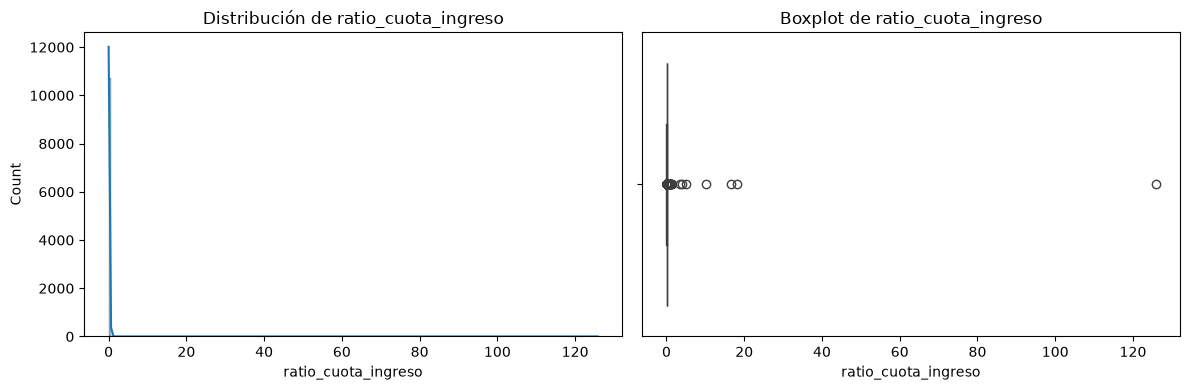

In [42]:
analizar_numerica(df, "ratio_cuota_ingreso")

### Interpretación de la relación cuota-ingreso

La variable derivada `ratio_cuota_ingreso` permite representar la proporción del salario del cliente comprometida con la cuota del crédito.

La mediana del indicador es aproximadamente 0,06, lo que significa que para un cliente típico la cuota representa cerca del 6 % de su salario reportado. El 75 % de los registros presenta una relación inferior al 10 %, mientras que el 95 % se encuentra por debajo de aproximadamente 19 %.

Sin embargo, la distribución presenta una fuerte asimetría hacia la derecha. Aunque el percentil 99 se encuentra alrededor de 35 %, existen valores extremadamente altos, alcanzando un máximo superior a 125 veces el salario reportado.

Estos casos extremos probablemente están relacionados con salarios muy bajos, inconsistencias en los datos o diferencias en la periodicidad o definición de las variables. Por esta razón, la relación cuota-ingreso debe utilizarse con precaución y los valores extremos requieren validación antes de emplearse en reglas de negocio o modelos predictivos.

In [43]:
df.loc[
    df["ratio_cuota_ingreso"] > 1,
    [
        "salario_cliente",
        "cuota_pactada",
        "ratio_cuota_ingreso",
        "capital_prestado",
        "plazo_meses",
        "Pago_atiempo"
    ]
].sort_values(
    "ratio_cuota_ingreso",
    ascending=False
).head(20)

,salario_cliente,cuota_pactada,ratio_cuota_ingreso,capital_prestado,plazo_meses,Pago_atiempo
361,1000,125802,125.80,840000,6,1
4863,31809,574403,18.06,3835051,6,1
6886,66667,1112633,16.69,7392000,6,1
5732,33334,335991,10.08,2232000,6,1
6274,30285,151265,4.99,1872000,12,1
8355,30285,120857,3.99,1416012,10,1
5164,30285,102439,3.38,1264800,12,1
6313,908526,1182159,1.30,7892784,6,0
7735,1000000,1269540,1.27,8433600,6,1
544,1556000,1752211,1.13,11640000,6,1


### Interpretación de los ratios cuota-ingreso extremos

La inspección de los registros con `ratio_cuota_ingreso` superior a 1 muestra que los valores extremos están asociados principalmente con salarios reportados excepcionalmente bajos en comparación con la cuota pactada.

Por ejemplo, se observan casos con salarios cercanos a 1.000, 30.000 o 60.000 unidades monetarias, mientras que las cuotas se encuentran en cientos de miles. Esto genera relaciones cuota-ingreso superiores al 100 % e incluso valores mayores a 100 veces el salario reportado.

Estos resultados sugieren que los valores extremos del indicador no necesariamente corresponden a cuotas extraordinariamente altas, sino que pueden estar amplificando posibles inconsistencias en `salario_cliente`.

Adicionalmente, varios de estos registros presentan `Pago_atiempo = 1`, por lo que no puede asumirse que una relación cuota-ingreso elevada implique directamente incumplimiento.

Antes de utilizar esta variable derivada en reglas de negocio o modelado, se recomienda validar la definición, unidad y periodicidad de `salario_cliente` y `cuota_pactada`, además de considerar métodos robustos para el tratamiento de valores extremos.

### 3.4 Análisis univariable de variables categóricas

Se analizan las principales variables categóricas para comprender la composición de la cartera y detectar posibles concentraciones o categorías con baja representación.

Además de la frecuencia absoluta, se calcula la participación porcentual de cada categoría.

In [44]:
def analizar_categorica(dataframe, columna):
    tabla = (
        dataframe[columna]
        .value_counts(dropna=False)
        .to_frame("cantidad")
    )

    tabla["porcentaje"] = (
        tabla["cantidad"] / len(dataframe) * 100
    )

    display(tabla)

    plt.figure(figsize=(8, 4))

    orden = (
        dataframe[columna]
        .value_counts(dropna=True)
        .index
    )

    sns.countplot(
        data=dataframe,
        x=columna,
        order=orden
    )

    plt.title(f"Distribución de {columna}")
    plt.xlabel(columna)
    plt.ylabel("Cantidad de registros")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    

,cantidad,porcentaje
tipo_laboral,,
Empleado,6754,62.75
Independiente,4009,37.25


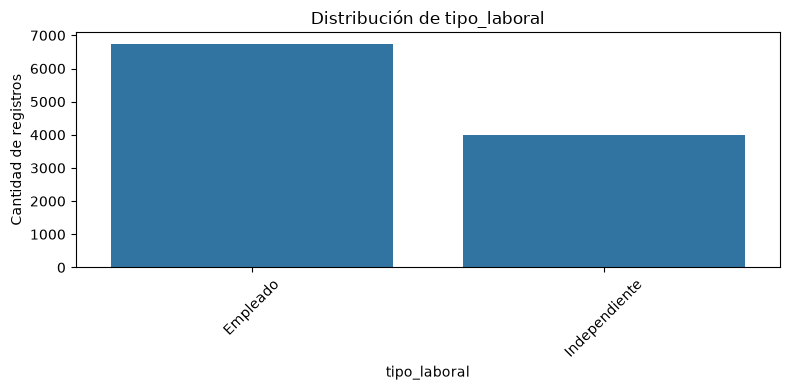

,cantidad,porcentaje
tipo_credito,,
4,7747,71.98
9,2876,26.72
10,116,1.08
6,21,0.20
7,2,0.02
68,1,0.01


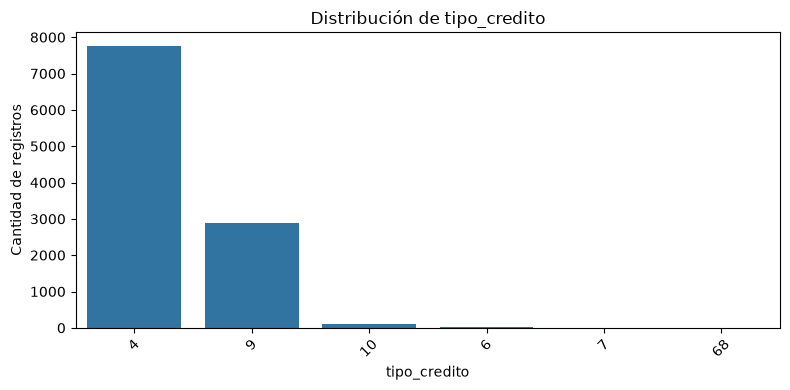

In [45]:
analizar_categorica(df, "tipo_laboral")
analizar_categorica(df, "tipo_credito")

In [46]:
df["tendencia_ingresos_limpia"] = (
    df["tendencia_ingresos"]
    .astype("string")
    .where(
        df["tendencia_ingresos"].isin(
            ["Creciente", "Estable", "Decreciente"]
        ),
        "Ausente o inválida"
    )
)

,cantidad,porcentaje
tendencia_ingresos_limpia,,
Creciente,5294,49.19
Ausente o inválida,2990,27.78
Decreciente,1291,11.99
Estable,1188,11.04


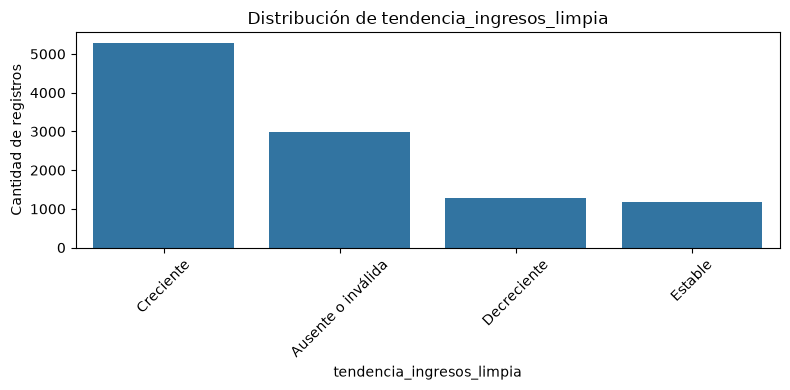

In [47]:
analizar_categorica(df, "tendencia_ingresos_limpia")

### Interpretación de las variables categóricas

En `tipo_laboral`, el 62,75 % de los registros corresponde a clientes empleados y el 37,25 % a clientes independientes. La cartera presenta una mayor concentración de clientes empleados, aunque ambos grupos cuentan con un número suficiente de observaciones para realizar comparaciones posteriores.

En `tipo_credito` se observa una concentración muy marcada en los códigos `4` y `9`, que representan aproximadamente el 71,98 % y 26,72 % de los registros, respectivamente. En conjunto, ambos códigos agrupan prácticamente toda la cartera. Los códigos `10`, `6`, `7` y `68` tienen una representación muy baja, por lo que cualquier tasa de incumplimiento calculada para estas categorías deberá interpretarse con precaución debido al reducido tamaño de muestra.

En `tendencia_ingresos_limpia`, aproximadamente el 49,19 % de los registros presenta una tendencia creciente, el 11,99 % decreciente y el 11,04 % estable. El 27,78 % restante corresponde a información ausente o valores inválidos.

La alta proporción de registros sin una categoría válida en `tendencia_ingresos` es especialmente relevante, ya que la ausencia de esta información podría tener significado de negocio y no debería imputarse automáticamente sin comprender primero su origen.

### 3.5 Análisis bivariable respecto al incumplimiento

Se analiza la relación entre diferentes características de los clientes y créditos y la variable auxiliar `incumplio`.

Para cada segmento se calcula:

- Cantidad total de créditos.
- Número de incumplimientos.
- Tasa de incumplimiento.

El tamaño de muestra se considera conjuntamente con la tasa observada para evitar conclusiones basadas en categorías con muy pocos registros.

In [48]:
def tabla_riesgo(dataframe, variable):
    resultado = (
        dataframe
        .groupby(variable, observed=True, dropna=False)
        .agg(
            creditos=("incumplio", "size"),
            incumplimientos=("incumplio", "sum"),
            tasa_incumplimiento=("incumplio", "mean")
        )
        .reset_index()
    )

    resultado["tasa_incumplimiento"] *= 100

    return resultado.sort_values(
        "tasa_incumplimiento",
        ascending=False
    )

In [49]:
riesgo_tipo_laboral = tabla_riesgo(
    df,
    "tipo_laboral"
)

display(riesgo_tipo_laboral)

,tipo_laboral,creditos,incumplimientos,tasa_incumplimiento
1,Independiente,4009,221,5.51
0,Empleado,6754,290,4.29


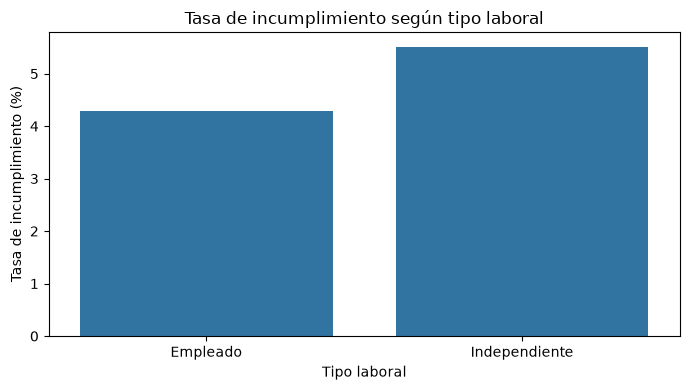

In [50]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=riesgo_tipo_laboral,
    x="tipo_laboral",
    y="tasa_incumplimiento"
)

plt.title("Tasa de incumplimiento según tipo laboral")
plt.xlabel("Tipo laboral")
plt.ylabel("Tasa de incumplimiento (%)")
plt.tight_layout()
plt.show()

### Interpretación del incumplimiento según tipo laboral

Los clientes independientes presentan una tasa de incumplimiento aproximada del 5,51 %, mientras que los empleados presentan una tasa cercana al 4,29 %.

Esto representa una diferencia de aproximadamente 1,22 puntos porcentuales y sugiere que, dentro de esta cartera, los clientes independientes presentan una frecuencia de incumplimiento ligeramente superior.

Sin embargo, esta diferencia no implica una relación causal. El comportamiento podría estar influenciado por otras variables como ingreso, nivel de endeudamiento, monto del crédito, plazo o puntaje crediticio.

Por esta razón, `tipo_laboral` puede considerarse una variable potencialmente útil para segmentación descriptiva, pero debería analizarse conjuntamente con otras características antes de utilizarse en decisiones de riesgo.

In [51]:
riesgo_tendencia = tabla_riesgo(
    df,
    "tendencia_ingresos_limpia"
)

display(riesgo_tendencia)

,tendencia_ingresos_limpia,creditos,incumplimientos,tasa_incumplimiento
2,Decreciente,1291,81,6.27
0,Ausente o inválida,2990,168,5.62
3,Estable,1188,55,4.63
1,Creciente,5294,207,3.91


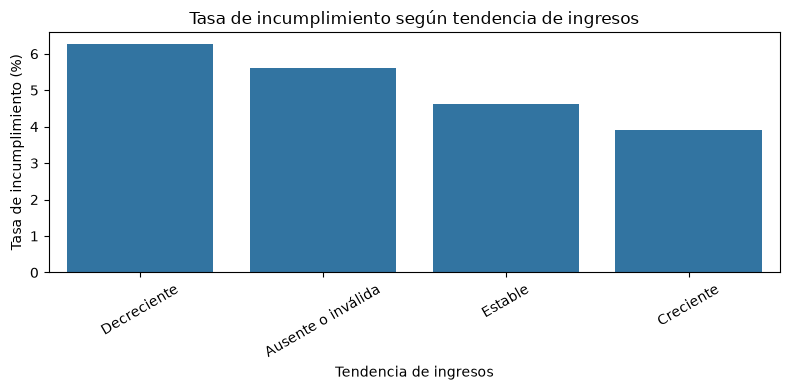

In [52]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=riesgo_tendencia,
    x="tendencia_ingresos_limpia",
    y="tasa_incumplimiento"
)

plt.title("Tasa de incumplimiento según tendencia de ingresos")
plt.xlabel("Tendencia de ingresos")
plt.ylabel("Tasa de incumplimiento (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Interpretación del incumplimiento según tendencia de ingresos

La tasa de incumplimiento presenta diferencias relevantes según la tendencia de ingresos reportada.

Los clientes con ingresos `Decrecientes` presentan la mayor tasa de incumplimiento, cercana al 6,27 %. En contraste, los clientes con ingresos `Crecientes` presentan una tasa aproximada del 3,91 %.

Los clientes con ingresos `Estables` se encuentran en una posición intermedia, con una tasa cercana al 4,63 %.

También resulta relevante que los registros clasificados como `Ausente o inválida` presentan una tasa de incumplimiento cercana al 5,62 %, superior a la observada en los grupos `Estable` y `Creciente`. Esto sugiere que la ausencia o mala calidad de esta información podría contener una señal relevante y no debería imputarse automáticamente sin analizar su origen.

En términos descriptivos, los resultados sugieren una asociación entre deterioro de los ingresos y mayor frecuencia de incumplimiento. Sin embargo, esta relación debe analizarse conjuntamente con otras variables financieras antes de concluir que exista un efecto causal.

In [53]:
df_datacredito = df[
    df["puntaje_datacredito"] > 0
].copy()

df_datacredito["quintil_datacredito"] = pd.qcut(
    df_datacredito["puntaje_datacredito"],
    q=5,
    duplicates="drop"
)

riesgo_datacredito = tabla_riesgo(
    df_datacredito,
    "quintil_datacredito"
)

display(riesgo_datacredito)

,quintil_datacredito,creditos,incumplimientos,tasa_incumplimiento
0,"(6.999, 750.0]",2170,185,8.53
2,"(778.0, 804.0]",2177,103,4.73
1,"(750.0, 778.0]",2078,91,4.38
3,"(804.0, 834.0]",2081,65,3.12
4,"(834.0, 999.0]",2105,56,2.66


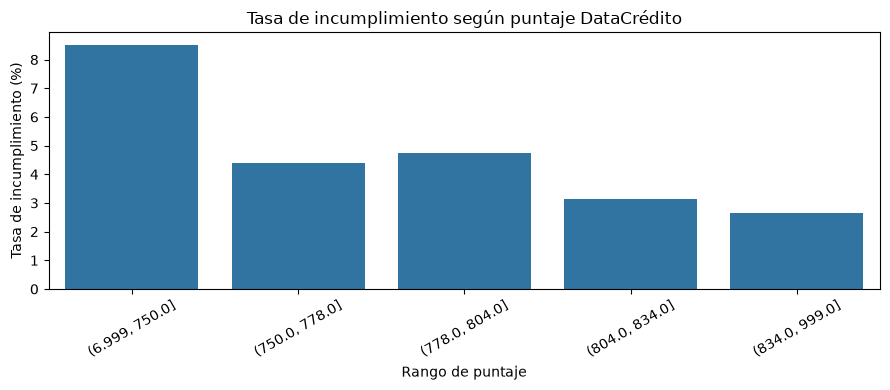

In [54]:
plt.figure(figsize=(9, 4))

sns.barplot(
    data=riesgo_datacredito,
    x="quintil_datacredito",
    y="tasa_incumplimiento"
)

plt.title("Tasa de incumplimiento según puntaje DataCrédito")
plt.xlabel("Rango de puntaje")
plt.ylabel("Tasa de incumplimiento (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Interpretación del incumplimiento según puntaje DataCrédito

El puntaje de DataCrédito presenta una asociación clara con la tasa de incumplimiento observada.

El quintil con los puntajes más bajos, aproximadamente entre 699 y 750 puntos, presenta una tasa de incumplimiento cercana al 8,53 %. En contraste, el quintil con los puntajes más altos, aproximadamente entre 834 y 999 puntos, presenta una tasa cercana al 2,66 %.

Esto significa que el grupo con menor puntaje presenta una frecuencia de incumplimiento superior a tres veces la observada en el grupo con mayor puntaje.

Aunque la relación no es perfectamente monotónica entre todos los quintiles intermedios, se observa una tendencia general de disminución del incumplimiento a medida que aumenta el puntaje de DataCrédito.

Este resultado sugiere que `puntaje_datacredito` podría ser una variable relevante para segmentación de riesgo y para una eventual etapa de modelado predictivo.

Sin embargo, el análisis excluyó provisionalmente los valores menores o iguales a cero. Antes de utilizar esta variable en producción se debe confirmar el rango oficial del puntaje y el significado de valores especiales como `0`, `-7` y `999`.

In [55]:
df["segmento_huella"] = pd.cut(
    df["huella_consulta"],
    bins=[-1, 2, 4, 6, np.inf],
    labels=[
        "0 a 2",
        "3 a 4",
        "5 a 6",
        "Más de 6"
    ]
)

riesgo_huella = tabla_riesgo(
    df,
    "segmento_huella"
)

display(riesgo_huella)

,segmento_huella,creditos,incumplimientos,tasa_incumplimiento
3,Más de 6,2013,150,7.45
2,5 a 6,1995,111,5.56
1,3 a 4,3340,150,4.49
0,0 a 2,3415,100,2.93


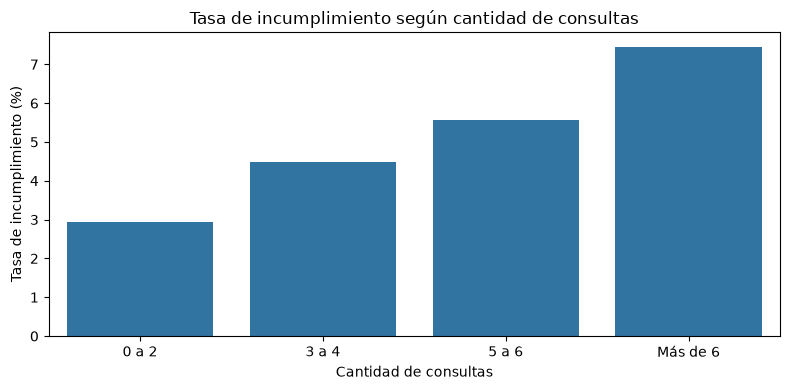

In [56]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=riesgo_huella,
    x="segmento_huella",
    y="tasa_incumplimiento"
)

plt.title("Tasa de incumplimiento según cantidad de consultas")
plt.xlabel("Cantidad de consultas")
plt.ylabel("Tasa de incumplimiento (%)")
plt.tight_layout()
plt.show()

### Interpretación del incumplimiento según cantidad de consultas

La variable `huella_consulta` presenta una relación creciente con la tasa de incumplimiento.

Los clientes con entre 0 y 2 consultas presentan una tasa de incumplimiento aproximada del 2,93 %. Esta tasa aumenta progresivamente a medida que crece la cantidad de consultas: alrededor de 4,49 % para clientes con 3 a 4 consultas, 5,56 % para quienes presentan entre 5 y 6, y 7,45 % para los clientes con más de 6 consultas.

En términos descriptivos, los clientes con más de 6 consultas presentan una frecuencia de incumplimiento superior a dos veces la observada en el grupo con hasta 2 consultas.

Este comportamiento sugiere que `huella_consulta` podría funcionar como un indicador relevante de riesgo. Una posible interpretación es que una mayor cantidad de consultas esté asociada con una mayor búsqueda de financiación o presión crediticia.

Sin embargo, esta relación no debe interpretarse como causal. Para utilizar esta variable en decisiones de negocio es necesario confirmar qué representa exactamente `huella_consulta`, cuál es su ventana temporal y si todas las consultas consideradas ocurrieron antes del otorgamiento del crédito.

In [60]:
df["quintil_capital"] = pd.qcut(
    df["capital_prestado"],
    q=5,
    duplicates="drop"
)

riesgo_capital = tabla_riesgo(
    df,
    "quintil_capital"
)

display(riesgo_capital)

,quintil_capital,creditos,incumplimientos,tasa_incumplimiento
4,"(3431657.2, 41444153.0]",2153,155,7.20
3,"(2299008.0, 3431657.2]",2152,94,4.37
0,"(359999.999, 1111080.0]",2154,92,4.27
2,"(1629925.0, 2299008.0]",2153,86,3.99
1,"(1111080.0, 1629925.0]",2151,84,3.91


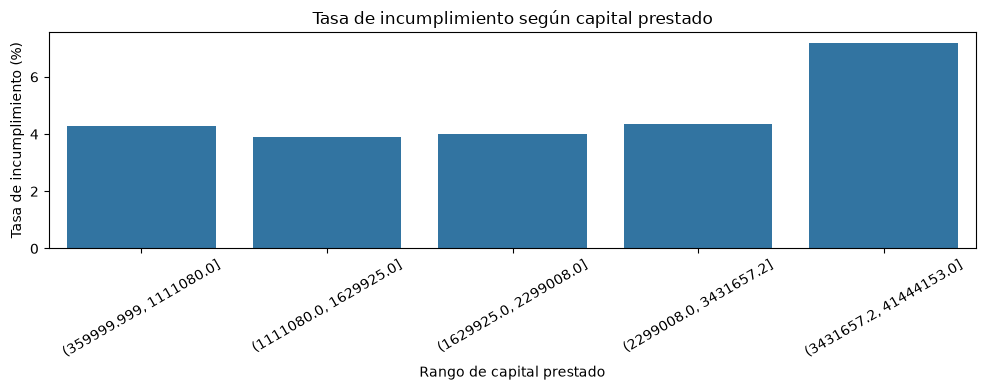

In [61]:
plt.figure(figsize=(10, 4))

sns.barplot(
    data=riesgo_capital,
    x="quintil_capital",
    y="tasa_incumplimiento"
)

plt.title("Tasa de incumplimiento según capital prestado")
plt.xlabel("Rango de capital prestado")
plt.ylabel("Tasa de incumplimiento (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Interpretación del incumplimiento según capital prestado

La tasa de incumplimiento se mantiene relativamente estable, alrededor del 4 %, en los cuatro primeros quintiles de capital prestado.

Sin embargo, el quintil correspondiente a los créditos de mayor monto presenta una tasa de incumplimiento cercana al 7,20 %, considerablemente superior al resto de los grupos.

Este resultado sugiere que los créditos de mayor valor podrían concentrar un nivel de riesgo superior. No obstante, el monto prestado no debería analizarse de forma aislada, ya que su efecto puede depender de variables como el ingreso del cliente, la cuota pactada, el plazo y el nivel de endeudamiento.

### 3.6 Análisis multivariable

Se analizan simultáneamente varias variables numéricas con el objetivo de identificar relaciones entre ellas y evaluar posibles asociaciones con la variable de incumplimiento.

Debido a la presencia de distribuciones asimétricas y valores extremos, se utiliza la correlación de Spearman, que permite evaluar relaciones monotónicas sin asumir normalidad.

In [62]:
variables_correlacion = [
    "capital_prestado",
    "plazo_meses",
    "edad_cliente",
    "salario_cliente",
    "total_otros_prestamos",
    "cuota_pactada",
    "puntaje_datacredito",
    "cant_creditosvigentes",
    "huella_consulta",
    "promedio_ingresos_datacredito",
    "ratio_cuota_ingreso",
    "incumplio"
]

correlacion_spearman = (
    df[variables_correlacion]
    .corr(method="spearman")
)

display(correlacion_spearman)

,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje_datacredito,cant_creditosvigentes,huella_consulta,promedio_ingresos_datacredito,ratio_cuota_ingreso,incumplio
capital_prestado,1.00,0.32,0.01,0.31,0.19,0.75,0.09,0.06,0.03,0.11,0.37,0.04
plazo_meses,0.32,1.00,-0.09,-0.13,-0.17,-0.31,-0.03,-0.00,0.03,0.08,-0.18,0.02
edad_cliente,0.01,-0.09,1.00,0.14,0.12,0.07,0.36,0.05,-0.22,-0.04,-0.08,-0.05
salario_cliente,0.31,-0.13,0.14,1.00,0.71,0.39,0.10,0.30,0.12,0.21,-0.52,0.00
total_otros_prestamos,0.19,-0.17,0.12,0.71,1.00,0.30,0.07,0.29,0.09,0.14,-0.36,-0.03
cuota_pactada,0.75,-0.31,0.07,0.39,0.30,1.00,0.11,0.07,0.01,0.05,0.52,0.01
puntaje_datacredito,0.09,-0.03,0.36,0.10,0.07,0.11,1.00,-0.04,-0.22,0.13,0.03,-0.09
cant_creditosvigentes,0.06,-0.00,0.05,0.30,0.29,0.07,-0.04,1.00,0.33,0.12,-0.18,-0.02
huella_consulta,0.03,0.03,-0.22,0.12,0.09,0.01,-0.22,0.33,1.00,0.03,-0.08,0.07
promedio_ingresos_datacredito,0.11,0.08,-0.04,0.21,0.14,0.05,0.13,0.12,0.03,1.00,-0.15,-0.05


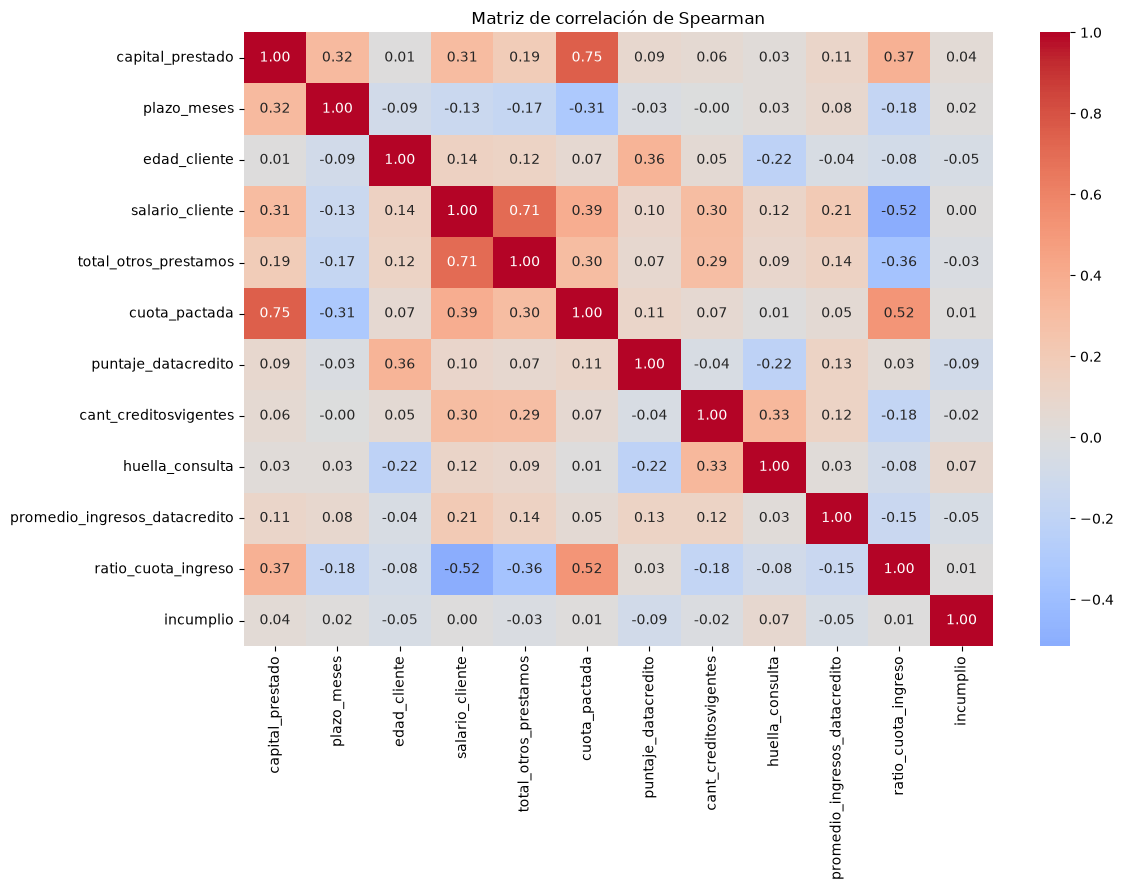

In [63]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlacion_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación de Spearman")
plt.tight_layout()
plt.show()

### Interpretación de la matriz de correlación

La matriz de correlación de Spearman permite identificar relaciones entre las variables numéricas sin asumir distribuciones normales.

Entre las asociaciones más fuertes se encuentra la relación entre `capital_prestado` y `cuota_pactada`, con una correlación aproximada de 0,75. Esta relación es coherente con el contexto del negocio, ya que créditos de mayor monto tienden a generar cuotas mayores.

También se observa una correlación aproximada de 0,71 entre `salario_cliente` y `total_otros_prestamos`, así como relaciones moderadas entre `cuota_pactada` y `ratio_cuota_ingreso` (0,52) y entre `salario_cliente` y dicho ratio (-0,52).

Respecto a la variable `incumplio`, las correlaciones individuales son relativamente bajas. Las asociaciones más relevantes corresponden a `puntaje_datacredito`, con una correlación negativa cercana a -0,09, y `huella_consulta`, con una correlación positiva cercana a 0,07.

Estas correlaciones son consistentes en dirección con los análisis bivariables anteriores: mayores puntajes de DataCrédito se asociaron con menor incumplimiento, mientras que un mayor número de consultas se relacionó con una mayor tasa de incumplimiento.

Sin embargo, una correlación baja no implica que una variable carezca de utilidad. Las relaciones con el incumplimiento pueden ser no lineales, depender de determinados segmentos o surgir de la interacción entre varias características.

### 3.7 Interacción entre puntaje DataCrédito y cantidad de consultas

Se analiza conjuntamente el puntaje de DataCrédito y la cantidad de consultas crediticias para determinar si la combinación de ambas características permite identificar segmentos con diferentes niveles de incumplimiento.

In [64]:
df_multivariable = df[
    df["puntaje_datacredito"] > 0
].copy()

df_multivariable["quintil_datacredito"] = pd.qcut(
    df_multivariable["puntaje_datacredito"],
    q=5,
    duplicates="drop"
)

df_multivariable["segmento_huella"] = pd.cut(
    df_multivariable["huella_consulta"],
    bins=[-1, 2, 4, 6, np.inf],
    labels=[
        "0 a 2",
        "3 a 4",
        "5 a 6",
        "Más de 6"
    ]
)

riesgo_multivariable = (
    df_multivariable
    .groupby(
        ["quintil_datacredito", "segmento_huella"],
        observed=True
    )
    .agg(
        creditos=("incumplio", "size"),
        incumplimientos=("incumplio", "sum"),
        tasa_incumplimiento=("incumplio", "mean")
    )
    .reset_index()
)

riesgo_multivariable["tasa_incumplimiento"] *= 100

display(riesgo_multivariable)

,quintil_datacredito,segmento_huella,creditos,incumplimientos,tasa_incumplimiento
0,"(6.999, 750.0]",0 a 2,387,17,4.39
1,"(6.999, 750.0]",3 a 4,608,46,7.57
2,"(6.999, 750.0]",5 a 6,484,46,9.50
3,"(6.999, 750.0]",Más de 6,691,76,11.00
4,"(750.0, 778.0]",0 a 2,520,13,2.50
5,"(750.0, 778.0]",3 a 4,645,29,4.50
6,"(750.0, 778.0]",5 a 6,417,20,4.80
7,"(750.0, 778.0]",Más de 6,496,29,5.85
8,"(778.0, 804.0]",0 a 2,656,17,2.59
9,"(778.0, 804.0]",3 a 4,722,39,5.40


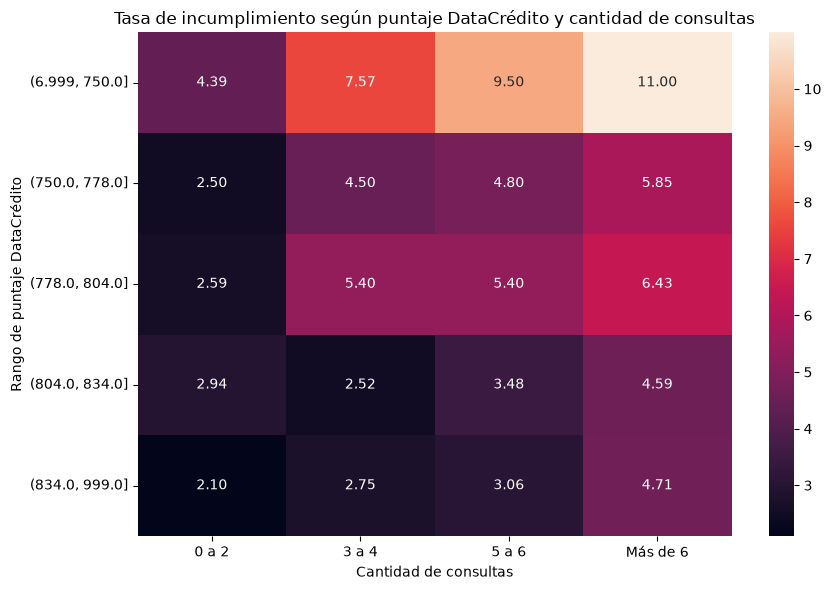

In [65]:
matriz_riesgo = riesgo_multivariable.pivot(
    index="quintil_datacredito",
    columns="segmento_huella",
    values="tasa_incumplimiento"
)

plt.figure(figsize=(9, 6))

sns.heatmap(
    matriz_riesgo,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Tasa de incumplimiento según puntaje DataCrédito y cantidad de consultas"
)
plt.xlabel("Cantidad de consultas")
plt.ylabel("Rango de puntaje DataCrédito")
plt.tight_layout()
plt.show()

### Interpretación de la interacción entre puntaje y consultas

El análisis conjunto de `puntaje_datacredito` y `huella_consulta` permite identificar segmentos con diferencias importantes en la tasa de incumplimiento.

Dentro del grupo con los puntajes de DataCrédito más bajos, la tasa de incumplimiento aumenta progresivamente con la cantidad de consultas. Los clientes con entre 0 y 2 consultas presentan una tasa cercana al 4,39 %, mientras que aquellos con más de 6 consultas alcanzan aproximadamente el 11,00 %.

En contraste, los clientes pertenecientes al quintil de puntaje más alto presentan tasas considerablemente menores. El segmento con puntaje alto y entre 0 y 2 consultas presenta una tasa aproximada del 2,10 %.

La combinación de bajo puntaje y alta cantidad de consultas identifica, por tanto, un segmento con una frecuencia de incumplimiento superior a cinco veces la observada en clientes con puntaje alto y pocas consultas.

Este resultado muestra que analizar variables de manera conjunta puede revelar patrones que no son evidentes al observar cada característica por separado. En una eventual etapa de segmentación o modelado, la interacción entre historial crediticio y comportamiento de consultas podría resultar especialmente relevante.

Estas asociaciones son descriptivas y no deben interpretarse como relaciones causales.

### 3.8 Revisión de variables irrelevantes o candidatas a exclusión

Se revisan variables que podrían aportar poca información, presentar baja variabilidad, contener problemas de calidad o implicar riesgo de fuga de información.

La decisión de excluir una variable no se realiza únicamente por criterios estadísticos; también debe considerar su significado de negocio y el momento en que la información está disponible.

In [66]:
revision_variables = pd.DataFrame({
    "variable": df.columns,
    "valores_unicos": [df[col].nunique(dropna=True) for col in df.columns],
    "porcentaje_nulos": [df[col].isna().mean() * 100 for col in df.columns]
})

display(
    revision_variables.sort_values(
        ["valores_unicos", "porcentaje_nulos"]
    )
)

,variable,valores_unicos,porcentaje_nulos
23,flag_target_invalido,1,0.00
25,flag_capital_no_positivo,1,0.00
26,flag_plazo_no_positivo,1,0.00
28,flag_huella_negativa,1,0.00
5,tipo_laboral,2,0.00
22,Pago_atiempo,2,0.00
24,flag_edad_fuera_rango,2,0.00
27,flag_salario_no_positivo,2,0.00
29,flag_tendencia_invalida,2,0.00
30,incumplio,2,0.00


In [67]:
candidatas_revision = pd.DataFrame([
    {
        "variable": "puntaje",
        "motivo": "Aproximadamente 87,4 % de los registros presentan el mismo valor.",
        "decision_provisional": "Mantener para trazabilidad, pero revisar antes de modelar."
    },
    {
        "variable": "fecha_prestamo",
        "motivo": "Alta cardinalidad y no debe utilizarse directamente como número.",
        "decision_provisional": "Mantener y derivar atributos temporales."
    },
    {
        "variable": "saldo_mora",
        "motivo": "Podría contener información posterior al otorgamiento del crédito.",
        "decision_provisional": "Validar temporalidad antes de utilizar como predictor."
    },
    {
        "variable": "saldo_total",
        "motivo": "Podría contener información posterior al otorgamiento del crédito.",
        "decision_provisional": "Validar temporalidad antes de utilizar como predictor."
    },
    {
        "variable": "saldo_principal",
        "motivo": "Podría contener información posterior al otorgamiento del crédito.",
        "decision_provisional": "Validar temporalidad antes de utilizar como predictor."
    },
    {
        "variable": "saldo_mora_codeudor",
        "motivo": "Presenta alta concentración en cero y requiere validación semántica.",
        "decision_provisional": "Mantener provisionalmente."
    }
])

display(candidatas_revision)

,variable,motivo,decision_provisional
0,puntaje,"Aproximadamente 87,4 % de los registros presen...","Mantener para trazabilidad, pero revisar antes..."
1,fecha_prestamo,Alta cardinalidad y no debe utilizarse directa...,Mantener y derivar atributos temporales.
2,saldo_mora,Podría contener información posterior al otorg...,Validar temporalidad antes de utilizar como pr...
3,saldo_total,Podría contener información posterior al otorg...,Validar temporalidad antes de utilizar como pr...
4,saldo_principal,Podría contener información posterior al otorg...,Validar temporalidad antes de utilizar como pr...
5,saldo_mora_codeudor,Presenta alta concentración en cero y requiere...,Mantener provisionalmente.


### Interpretación de variables candidatas a revisión

No se identifican variables que deban eliminarse automáticamente en esta etapa.

Sin embargo, `puntaje` presenta una variabilidad efectiva muy reducida, debido a que aproximadamente el 87,4 % de los registros comparte el mismo valor. Esto limita potencialmente su capacidad informativa.

Las variables relacionadas con saldos requieren especial precaución. Antes de utilizarlas en una etapa predictiva debe confirmarse si representan información disponible al momento de otorgar el crédito o si fueron calculadas posteriormente. En este último caso podrían generar fuga de información (`target leakage`).

`fecha_prestamo` se conserva, pero su utilidad analítica se encuentra principalmente en atributos derivados como año, mes o periodo, más que en utilizar la fecha completa como variable numérica.

Por estas razones, las variables se mantienen en el conjunto de datos para conservar trazabilidad, pero algunas quedan marcadas para revisión antes de una eventual etapa de modelado.

### 3.9 Transformaciones aplicadas y atributos derivados

Durante la preparación y exploración de los datos se aplicaron transformaciones orientadas a mejorar la consistencia, interpretabilidad y utilidad analítica del conjunto de datos.

Las principales transformaciones realizadas fueron:

- Normalización de espacios en blanco y representaciones de valores nulos.
- Conversión de `fecha_prestamo` a tipo fecha y hora.
- Conversión explícita de variables numéricas.
- Conversión de variables categóricas a tipo `category`.
- Creación de banderas de calidad para identificar edades fuera de rango, salarios no positivos y tendencias de ingresos inválidas.
- Creación de la variable auxiliar `incumplio` para facilitar la interpretación de las tasas de riesgo.
- Creación de una versión limpia de `tendencia_ingresos`.
- Segmentación de variables numéricas en rangos o quintiles para facilitar comparaciones.
- Creación de la variable derivada `ratio_cuota_ingreso`.

Estas transformaciones no modifican de forma irreversible los datos originales, ya que se conserva una copia inicial del DataFrame en `df_raw`.

In [68]:
transformaciones_resumen = pd.DataFrame([
    {
        "transformacion": "Normalización de nulos",
        "variables": "Todas",
        "objetivo": "Unificar representaciones de ausencia"
    },
    {
        "transformacion": "Conversión de fecha",
        "variables": "fecha_prestamo",
        "objetivo": "Permitir análisis temporal"
    },
    {
        "transformacion": "Conversión numérica",
        "variables": "Variables monetarias, conteos y puntajes",
        "objetivo": "Permitir análisis estadístico"
    },
    {
        "transformacion": "Conversión categórica",
        "variables": "tipo_credito, tipo_laboral, tendencia_ingresos",
        "objetivo": "Representar correctamente variables nominales"
    },
    {
        "transformacion": "Flags de calidad",
        "variables": "edad, salario, tendencia, target, etc.",
        "objetivo": "Identificar anomalías sin eliminar registros"
    },
    {
        "transformacion": "Variable auxiliar de incumplimiento",
        "variables": "Pago_atiempo",
        "objetivo": "Facilitar interpretación de tasas de riesgo"
    },
    {
        "transformacion": "Limpieza de tendencia de ingresos",
        "variables": "tendencia_ingresos",
        "objetivo": "Separar categorías válidas de valores ausentes o inválidos"
    },
    {
        "transformacion": "Ratio cuota-ingreso",
        "variables": "cuota_pactada, salario_cliente",
        "objetivo": "Representar capacidad relativa de pago"
    }
])

display(transformaciones_resumen)

,transformacion,variables,objetivo
0,Normalización de nulos,Todas,Unificar representaciones de ausencia
1,Conversión de fecha,fecha_prestamo,Permitir análisis temporal
2,Conversión numérica,"Variables monetarias, conteos y puntajes",Permitir análisis estadístico
3,Conversión categórica,"tipo_credito, tipo_laboral, tendencia_ingresos",Representar correctamente variables nominales
4,Flags de calidad,"edad, salario, tendencia, target, etc.",Identificar anomalías sin eliminar registros
5,Variable auxiliar de incumplimiento,Pago_atiempo,Facilitar interpretación de tasas de riesgo
6,Limpieza de tendencia de ingresos,tendencia_ingresos,Separar categorías válidas de valores ausentes...
7,Ratio cuota-ingreso,"cuota_pactada, salario_cliente",Representar capacidad relativa de pago


## 4. Conclusiones principales

El análisis exploratorio permitió caracterizar la cartera, identificar problemas de calidad de datos y encontrar variables asociadas con una mayor o menor frecuencia de incumplimiento.

Los principales hallazgos fueron:

1. La variable objetivo presenta un fuerte desbalance. Aproximadamente el 95,25 % de los créditos fueron pagados a tiempo, mientras que el 4,75 % presentó incumplimiento.

2. Se identificaron problemas de calidad relevantes, entre ellos edades superiores a 100 años, salarios iguales a cero, valores fuera del dominio esperado en `tendencia_ingresos` y valores potencialmente especiales en las variables de puntaje.

3. `puntaje_datacredito` mostró una relación clara con el incumplimiento. El quintil con menor puntaje presentó una tasa cercana al 8,53 %, mientras que el quintil superior presentó aproximadamente 2,66 %.

4. `huella_consulta` presentó una asociación creciente con el incumplimiento. Los clientes con entre 0 y 2 consultas tuvieron una tasa cercana al 2,93 %, frente a aproximadamente 7,45 % entre quienes registraron más de 6 consultas.

5. Los clientes con tendencia de ingresos decreciente presentaron una tasa de incumplimiento superior a la observada en clientes con ingresos estables o crecientes.

6. El grupo de créditos con mayor capital prestado presentó una tasa de incumplimiento cercana al 7,20 %, superior a la observada en los demás quintiles.

7. El análisis multivariable mostró que la combinación de un bajo puntaje de DataCrédito y una alta cantidad de consultas concentra el mayor nivel de riesgo observado. El segmento con menor puntaje y más de 6 consultas alcanzó una tasa de incumplimiento aproximada del 11 %, frente a alrededor del 2,10 % entre clientes con puntaje alto y pocas consultas.

8. Algunas variables, especialmente `puntaje` y las relacionadas con saldos, requieren validación adicional antes de utilizarse en un proceso predictivo.

## 5. Recomendaciones

A partir de los hallazgos obtenidos se proponen las siguientes acciones:

- Validar con el área de negocio el diccionario oficial de variables y los rangos permitidos.

- Confirmar el significado de valores especiales en `puntaje_datacredito`, especialmente `0`, valores negativos y `999`.

- Investigar los registros con edades superiores a 100 años y salarios extremadamente bajos o altos antes de corregirlos o excluirlos.

- Implementar reglas automáticas de calidad para detectar valores fuera de dominio, tipos incorrectos y rangos no plausibles.

- Considerar `puntaje_datacredito` y `huella_consulta` como variables relevantes para futuras segmentaciones de riesgo.

- Analizar conjuntamente varias características en lugar de utilizar reglas basadas en una única variable.

- Validar la temporalidad de las variables relacionadas con saldos antes de utilizarlas en un modelo para evitar fuga de información.

- En una eventual etapa de modelado, utilizar métricas adecuadas para clases desbalanceadas como `precision`, `recall`, `F1-score`, PR-AUC y matriz de confusión, en lugar de depender únicamente de `accuracy`.

## 6. Limitaciones del análisis

Los resultados obtenidos deben interpretarse teniendo en cuenta las siguientes limitaciones:

- No se proporcionó un diccionario oficial de datos, por lo que varias interpretaciones son provisionales.

- Las relaciones identificadas son asociaciones estadísticas y no implican causalidad.

- Algunas categorías presentan muy pocos registros, lo que limita la confiabilidad de sus tasas individuales.

- Existen valores atípicos y posibles inconsistencias cuyo significado no puede determinarse únicamente a partir del conjunto de datos.

- No se conoce con certeza el momento de generación de todas las variables, especialmente aquellas relacionadas con saldos y mora.

- No se ha validado si todos los créditos, especialmente los más recientes, tuvieron suficiente tiempo de observación para evidenciar un eventual incumplimiento.

- El alcance del ejercicio corresponde principalmente a transformación y análisis exploratorio, por lo que no se entrenó un modelo predictivo.